# 📍 K-Nearest Neighbors — Predict by Asking the Closest Examples

> **What you'll learn:** how k-nearest neighbours (KNN) makes predictions with no training step, which distance to use and when, how to choose `k` with cross-validation, why feature scaling and the curse of dimensionality decide whether KNN works, how KD-trees, ball trees and approximate search make it fast, and how to use it for regression and imbalanced classes. You will build KNN from scratch and match scikit-learn exactly.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Logistic Regression](04_Logistic_Regression.ipynb) (classification, probabilities, decision boundaries) · [Scikit-Learn](02_Scikit_Learn.ipynb) (pipelines, cross-validation, grid search) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · imbalanced-learn 0.14 · pynndescent 0.6 · numpy 2.5 · pandas 3.0 |
| **Interview relevance** | ⭐⭐⭐ High — "implement KNN in NumPy", "how do you choose k?", "why must you scale features?", the curse of dimensionality, KD-tree vs brute force, and approximate nearest neighbours for vector search |

## 🤔 What Is K-Nearest Neighbors?

You move to a new city and want to guess the rent of a flat. You don't build a formula. You look at the **5 most similar flats nearby** (same size, same street) and take their average rent.

That is **k-nearest neighbours (KNN)**:

1. **Store** every training example. That's the whole "training".
2. To predict a new point, **measure the distance** to every stored example.
3. Take the **k closest** ones (the *neighbours*).
4. **Classification:** majority vote of their labels. **Regression:** average of their values.

```
           ●  ●                 ● = class A,  ▲ = class B,  ★ = new point
       ●     ●    ▲
         ● ★   ▲    ▲           k = 3 → the 3 closest are ●, ●, ▲ → predict ●
            ●    ▲
```

- **k** = how many neighbours vote. Small k follows every wiggle; large k smooths things out.
- **Distance** = how "closeness" is measured (straight-line Euclidean by default).
- **Lazy learner** = a model that does its work at prediction time instead of training time.
- **Non-parametric** = the model has no fixed set of learned weights; the stored data *is* the model.

## 🎯 Why It Matters

- **It is the simplest strong baseline.** On small, low-dimensional, well-scaled data, KNN is often competitive with far fancier models, and it needs almost no tuning.
- **Nearest-neighbour search is everywhere in modern AI.** Recommendations ("customers like you"), duplicate detection, image search, anomaly detection and **retrieval for RAG and vector databases** are all "find the closest vectors" at scale.
- **It teaches the core geometry of ML:** distance metrics, feature scaling, bias–variance and the curse of dimensionality all show up here in their clearest form.
- **In interviews** KNN is a favourite: *"implement KNN with only NumPy"*, *"how do you choose k?"*, *"why does KNN need scaling?"*, *"what is the curse of dimensionality?"*, *"KNN is slow at prediction — how would you serve it for 100 million items?"* This notebook practises every one.

## 🃏 Algorithm Card

| | K-Nearest Neighbors |
|---|---|
| **Learning type** | Supervised, instance-based (lazy), non-parametric |
| **Tasks** | Classification, regression; the same search powers recommendations, retrieval, anomaly detection and imputation (`KNNImputer`) |
| **Model / objective** | No loss is optimized. Predict with the (weighted) majority vote or mean of the k closest training points; $\hat P(y=c \mid x) = \frac{1}{k}\sum_{i \in N_k(x)} \mathbb{1}[y_i = c]$ |
| **Key hyperparameters (typical ranges)** | `n_neighbors` (1–50, odd for binary), `weights` (`"uniform"` / `"distance"`), `metric` + `p` (Euclidean, Manhattan, cosine…), `algorithm` (`"auto"`, `"kd_tree"`, `"ball_tree"`, `"brute"`), `leaf_size` (20–50, speed only) |
| **Needs feature scaling?** | **Yes, always** — distance adds up raw units, so the largest-range feature dominates |
| **Handles missing values / categoricals?** | No / no — impute first (`SimpleImputer`, `KNNImputer`) and one-hot encode (or use Hamming/Gower-style distances) |
| **Training & prediction complexity** | Fit: O(1) for brute force (store data), O(n log n) to build a tree. Predict per query: O(n·d) brute force; roughly O(log n) with trees in low dimensions, degrading towards O(n) as d grows. Memory: O(n·d) |
| **Interpretability** | High locally ("these 5 similar cases were approved"), no global feature weights |
| **Strengths** | No training, adapts to any decision-boundary shape, naturally multi-class, new data is added instantly, few hyperparameters |
| **Weaknesses** | Slow and memory-hungry at prediction time, sensitive to scaling and irrelevant features, breaks down in high dimensions, coarse probabilities |
| **Use it when** | Low-to-moderate dimensions (or good embeddings), small-to-medium n, irregular boundaries, you need a quick baseline or "show me similar examples" |
| **Avoid it when** | Many raw/noisy features, strict low-latency serving on huge data without an ANN index, you need calibrated probabilities or a compact model |
| **Best libraries** | scikit-learn (`KNeighborsClassifier`, `KNeighborsRegressor`, `NearestNeighbors`), imbalanced-learn (resampling pipelines), approximate search: pynndescent, FAISS, hnswlib, vector databases |

## ✅ By the End You Can

- [ ] Explain lazy learning and predict a label by hand from the k nearest neighbours
- [ ] Choose a distance metric for numeric, text-like and binary data, and scale features correctly inside a pipeline
- [ ] Pick `k` and `weights` with cross-validation and explain the bias–variance picture with decision boundaries
- [ ] Measure the curse of dimensionality and the speed of brute force vs KD-tree vs ball tree vs approximate search
- [ ] Use KNN for regression and imbalanced classification without fooling yourself with accuracy
- [ ] Implement a vectorized KNN classifier and regressor from scratch that match scikit-learn

## 📋 Table of Contents

1. [The Idea: Lazy Learning](#1.-The-Idea:-Lazy-Learning-🟢)
2. [Distance Metrics](#2.-Distance-Metrics-🟢)
3. [Feature Scaling: Unscaled vs Scaled](#3.-Feature-Scaling:-Unscaled-vs-Scaled-🟢)
4. [Choosing k: Bias, Variance and Decision Boundaries](#4.-Choosing-k:-Bias,-Variance-and-Decision-Boundaries-🟡)
5. [Uniform vs Distance Weights](#5.-Uniform-vs-Distance-Weights-🟡)
6. [The Math: KNN as a Local Probability Estimate](#6.-The-Math:-KNN-as-a-Local-Probability-Estimate-🟡)
7. [The Curse of Dimensionality](#7.-The-Curse-of-Dimensionality-🔴)
8. [Assumptions and When They Break](#8.-Assumptions-and-When-They-Break-🟡)
9. [Brute Force, KD-Tree and Ball Tree](#9.-Brute-Force,-KD-Tree-and-Ball-Tree-🔴)
10. [KNN Regression](#10.-KNN-Regression-🟢)
11. [KNN With Imbalanced Classes](#11.-KNN-With-Imbalanced-Classes-🟡)
12. [Approximate Nearest Neighbours at Scale](#12.-Approximate-Nearest-Neighbours-at-Scale-🔴)
13. [A Fair Head-to-Head Comparison](#13.-A-Fair-Head-to-Head-Comparison-🟡)
- [🃏 Algorithm Card](#🃏-Algorithm-Card) · [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Fashion-MNIST-With-PCA-+-KNN) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

**Data (all real):** wine chemistry and handwritten digits ship with scikit-learn. California housing (~11 MB), the mammography screening dataset (OpenML, <1 MB) and, later, Fashion-MNIST (OpenML, ~30 MB) are downloaded once and cached in `_outputs/sklearn_data/`.

In [1]:
# %pip install -q "scikit-learn>=1.6" "imbalanced-learn>=0.13" "pynndescent>=0.5" "pandas>=2.2" matplotlib

import gc
import sys
import time
from functools import partial
from pathlib import Path

import imblearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynndescent
from matplotlib.colors import ListedColormap
import sklearn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as make_imb_pipeline
from sklearn.datasets import fetch_california_housing, fetch_openml, load_digits, load_wine
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    pairwise_distances,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
    TunedThresholdClassifierCV,
    cross_val_score,
    cross_validate,
    train_test_split,
    validation_curve,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor, NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Binarizer, MinMaxScaler, StandardScaler

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | imbalanced-learn {imblearn.__version__} | "
      f"pynndescent {pynndescent.__version__} | numpy {np.__version__} | pandas {pd.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 4)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
DATA_HOME = OUTPUT_DIR / "sklearn_data"    # dataset download cache
DATA_HOME.mkdir(parents=True, exist_ok=True)


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (bool, np.bool_, str)):
        ok = got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | scikit-learn 1.9.1 | imbalanced-learn 0.14.2 | pynndescent 0.6.0 | numpy 2.5.3 | pandas 3.0.5


In [2]:
wine = load_wine(as_frame=True)
X_wine, y_wine = wine.data, wine.target
digits = load_digits()
housing = fetch_california_housing(data_home=DATA_HOME, as_frame=True)
mammo = fetch_openml(data_id=310, as_frame=True, data_home=DATA_HOME, parser="pandas")

print(f"wine        : {X_wine.shape}  classes {np.bincount(y_wine)}")
print(f"digits      : {digits.data.shape}  10 classes, 8×8 pixel intensities 0–16")
print(f"housing     : {housing.data.shape}  target = median house value (×$100k)")
print(f"mammography : {mammo.data.shape}  positives {(mammo.target == '1').mean():.1%}")

wine        : (178, 13)  classes [59 71 48]
digits      : (1797, 64)  10 classes, 8×8 pixel intensities 0–16
housing     : (20640, 8)  target = median house value (×$100k)
mammography : (11183, 6)  positives 2.3%


## 1. The Idea: Lazy Learning 🟢

Let's classify one wine by hand using two chemical measurements, **alcohol** and **flavanoids**, and compare with scikit-learn. We standardize both features first (Section 3 explains why) using the **training rows only**.

In [3]:
features_2d = ["alcohol", "flavanoids"]
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X_wine[features_2d], y_wine, test_size=0.25,
                                              stratify=y_wine, random_state=SEED)
scaler_2d = StandardScaler().fit(X2_tr)
Z2_tr, Z2_te = scaler_2d.transform(X2_tr), scaler_2d.transform(X2_te)
y2_tr, y2_te = y2_tr.to_numpy(), y2_te.to_numpy()

query = Z2_te[0]
distances = np.sqrt(((Z2_tr - query) ** 2).sum(axis=1))     # Euclidean distance to every training wine
nearest = np.argsort(distances)[:5]                          # the 5 closest
by_hand = np.bincount(y2_tr[nearest]).argmax()               # majority vote

print(pd.DataFrame({"train row": nearest, "distance": distances[nearest], "class": y2_tr[nearest]}).to_string(index=False))
knn_2d = KNeighborsClassifier(n_neighbors=5).fit(Z2_tr, y2_tr)
print(f"\nby hand → class {by_hand} | scikit-learn → class {knn_2d.predict(query[None, :])[0]} | true class {y2_te[0]}")
assert by_hand == knn_2d.predict(query[None, :])[0]

 train row  distance  class
        55    0.1202      0
        54    0.2016      0
        71    0.2070      0
       122    0.2322      0
        16    0.2531      0

by hand → class 0 | scikit-learn → class 0 | true class 0


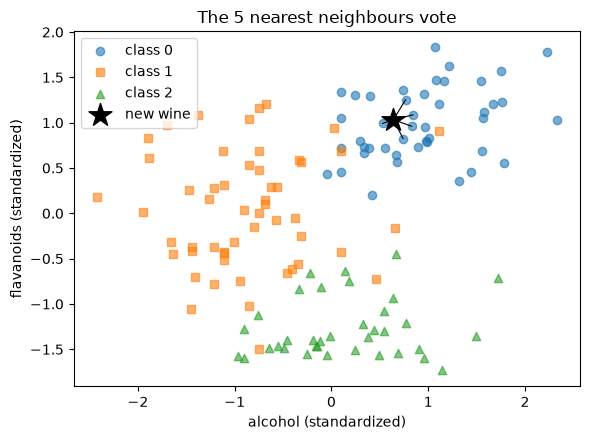

In [4]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for c, marker in zip(range(3), ["o", "s", "^"]):
    ax.scatter(*Z2_tr[y2_tr == c].T, marker=marker, alpha=0.6, label=f"class {c}")
for i in nearest:
    ax.plot([query[0], Z2_tr[i, 0]], [query[1], Z2_tr[i, 1]], "k-", lw=0.8)
ax.scatter(*query, marker="*", s=300, c="black", label="new wine")
ax.set(xlabel="alcohol (standardized)", ylabel="flavanoids (standardized)", title="The 5 nearest neighbours vote")
ax.legend()
plt.tight_layout()
plt.show()

**"Lazy" in numbers.** An *eager* model like linear regression does its work in `fit` and predicts with one cheap formula. KNN's `fit` just stores the data; all the work happens in `predict`. We time both on 15,000 California houses.

In [5]:
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(housing.data.to_numpy(), housing.target.to_numpy(),
                                              test_size=0.25, random_state=SEED)
scaler_h = StandardScaler().fit(Xh_tr)
Zh_tr, Zh_te = scaler_h.transform(Xh_tr), scaler_h.transform(Xh_te)

timing_rows = []
for name, model in [("LinearRegression (eager)", LinearRegression()),
                    ("KNeighborsRegressor (lazy)", KNeighborsRegressor(n_neighbors=10, algorithm="brute"))]:
    start = time.perf_counter(); model.fit(Zh_tr, yh_tr); fit_ms = (time.perf_counter() - start) * 1000
    start = time.perf_counter(); model.predict(Zh_te); pred_ms = (time.perf_counter() - start) * 1000
    timing_rows.append({"model": name, "fit ms": fit_ms, f"predict ms ({len(Zh_te):,} rows)": pred_ms})
timing = pd.DataFrame(timing_rows).set_index("model")
print(timing.round(2))
knn_row = timing.loc["KNeighborsRegressor (lazy)"]
print(f"\nKNN spends {knn_row.iloc[1] / max(knn_row.iloc[0], 1e-3):.0f}× longer predicting than fitting "
      f"(it stored all {model.n_samples_fit_:,} training rows).")

                            fit ms  predict ms (5,160 rows)
model                                                      
LinearRegression (eager)      1.17                     0.08
KNeighborsRegressor (lazy)    0.12                    31.91

KNN spends 275× longer predicting than fitting (it stored all 15,480 training rows).


### ✍️ Your Turn

The 5 nearest neighbours of a wine have labels `[2, 0, 2, 1, 2]`. Compute the majority-vote prediction `vote` with NumPy (no loops).

In [6]:
neighbour_labels = np.array([2, 0, 2, 1, 2])
vote = None  # TODO: your code here
check("vote", vote, 2, hint="np.bincount counts each label; argmax picks the most common.")

⏳ vote: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
neighbour_labels = np.array([2, 0, 2, 1, 2])
vote = np.bincount(neighbour_labels).argmax()
check("vote", vote, 2)
```

`np.bincount` gives `[1, 1, 3]` (one 0, one 1, three 2s). On a tie, `argmax` returns the **lowest** label — scikit-learn breaks ties the same way.
</details>

> 💡 **Interview angle:** "What does KNN learn during training?" — nothing but the data itself (plus an optional search index). That's why it's called lazy / instance-based: fit is O(1) for brute force, and the O(n·d) cost moves to every prediction.

## 2. Distance Metrics 🟢

"Nearest" depends on how you measure distance. For two points $a, b$ with $d$ features:

| Metric | Formula | Good for |
|---|---|---|
| **Euclidean** (L2) | $\sqrt{\sum_j (a_j - b_j)^2}$ | continuous, scaled features; the default |
| **Manhattan** (L1, city block) | $\sum_j \lvert a_j - b_j\rvert$ | high-ish dimensions, outliers (no squaring), grid-like movement |
| **Minkowski** ($p$) | $\left(\sum_j \lvert a_j - b_j\rvert^p\right)^{1/p}$ | the family: $p=1$ Manhattan, $p=2$ Euclidean, $p\to\infty$ Chebyshev |
| **Chebyshev** (L∞) | $\max_j \lvert a_j - b_j\rvert$ | "worst single feature" tolerance checks |
| **Cosine distance** | $1 - \dfrac{a \cdot b}{\lVert a\rVert \lVert b\rVert}$ | text, embeddings — direction matters, length doesn't |
| **Hamming** | fraction of positions where $a_j \ne b_j$ | binary / categorical codes, bit-strings |

Scikit-learn's default is `metric="minkowski", p=2`, which is Euclidean.

In [7]:
a, b = digits.data[0], digits.data[10]                     # two images of the digit 0
manual = {
    "euclidean": np.sqrt(((a - b) ** 2).sum()),
    "manhattan": np.abs(a - b).sum(),
    "minkowski p=3": (np.abs(a - b) ** 3).sum() ** (1 / 3),
    "chebyshev": np.abs(a - b).max(),
    "cosine": 1 - a @ b / (np.linalg.norm(a) * np.linalg.norm(b)),
    "hamming (binarized)": ((a > 7) != (b > 7)).mean(),
}
library = {
    "euclidean": pairwise_distances([a], [b], metric="euclidean")[0, 0],
    "manhattan": pairwise_distances([a], [b], metric="manhattan")[0, 0],
    "minkowski p=3": pairwise_distances([a], [b], metric="minkowski", p=3)[0, 0],
    "chebyshev": pairwise_distances([a], [b], metric="chebyshev")[0, 0],
    "cosine": pairwise_distances([a], [b], metric="cosine")[0, 0],
    "hamming (binarized)": pairwise_distances([a > 7], [b > 7], metric="hamming")[0, 0],
}
for name in manual:
    assert np.isclose(manual[name], library[name]), name
    print(f"{name:20s} {manual[name]:8.3f}")
print("✅ every hand formula matches sklearn.metrics.pairwise_distances")

euclidean              23.707
manhattan             114.000
minkowski p=3          15.232
chebyshev              10.000
cosine                  0.081
hamming (binarized)     0.047
✅ every hand formula matches sklearn.metrics.pairwise_distances


Which metric works best is an empirical question. We compare them on digits with **the same 5 folds** for every metric. Hamming needs binary features, so that pipeline first turns each pixel into ink / no ink with `Binarizer`.

In [8]:
digit_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
metric_models = {
    "euclidean": KNeighborsClassifier(metric="euclidean"),
    "manhattan": KNeighborsClassifier(metric="manhattan"),
    "minkowski p=3": KNeighborsClassifier(metric="minkowski", p=3),
    "chebyshev": KNeighborsClassifier(metric="chebyshev"),
    "cosine": KNeighborsClassifier(metric="cosine"),
    "hamming (binarized)": make_pipeline(Binarizer(threshold=7), KNeighborsClassifier(metric="hamming")),
}
metric_scores = pd.Series({name: cross_val_score(model, digits.data, digits.target, cv=digit_folds).mean()
                           for name, model in metric_models.items()}, name="5-fold accuracy")
print(metric_scores.sort_values(ascending=False).round(4))
print(f"\nBest: {metric_scores.idxmax()} | worst: {metric_scores.idxmin()} "
      f"({metric_scores.max() - metric_scores.min():.3f} apart)")

cosine                 0.9878
minkowski p=3          0.9877
euclidean              0.9872
manhattan              0.9827
chebyshev              0.9750
hamming (binarized)    0.9421
Name: 5-fold accuracy, dtype: float64

Best: cosine | worst: hamming (binarized) (0.046 apart)


**Cosine ignores length.** Now a *controlled* experiment on the real images: we dim every test digit by a random brightness factor between 0.2 and 0.6 (like a faded scan). Euclidean distance sees a dim "0" as far from every bright "0"; cosine distance only looks at the pattern of ink.

In [9]:
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(digits.data, digits.target, test_size=0.3,
                                              stratify=digits.target, random_state=SEED)
dimming = rng.uniform(0.2, 0.6, size=(len(Xd_te), 1))
for metric in ["euclidean", "cosine"]:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric).fit(Xd_tr, yd_tr)
    print(f"{metric:9s} original test {knn.score(Xd_te, yd_te):.3f} | dimmed test {knn.score(Xd_te * dimming, yd_te):.3f}")

euclidean original test 0.987 | dimmed test 0.841
cosine    original test 0.983 | dimmed test 0.983


### ✍️ Your Turn

Compute the **cosine distance** between `u = [3, 4]` and `v = [4, 3]` with NumPy.

In [10]:
u = np.array([3.0, 4.0])
v = np.array([4.0, 3.0])
cosine_distance = None  # TODO: your code here
check("cosine_distance", cosine_distance, 0.04, hint="1 - (u @ v) / (norm(u) * norm(v)).")

⏳ cosine_distance: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
u = np.array([3.0, 4.0])
v = np.array([4.0, 3.0])
cosine_distance = 1 - (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))
check("cosine_distance", cosine_distance, 0.04)
```

`u @ v = 24` and both lengths are 5, so the cosine similarity is 24/25 = 0.96 and the distance is 0.04.
</details>

> 💡 **Interview angle:** "Which distance would you use for text embeddings?" — cosine (or dot product on normalized vectors), because an embedding's direction carries the meaning and its length mostly reflects things like document length. On L2-normalized vectors, ranking by Euclidean distance and by cosine gives the same neighbours: $\lVert a-b\rVert^2 = 2 - 2\cos(a,b)$.

## 3. Feature Scaling: Unscaled vs Scaled 🟢

Distances add raw numbers. If one feature is measured in the thousands and another below 1, the big one decides who is "near" all by itself.

In the wine data, **proline** ranges into the 1,000s while **hue** stays below 2. Let's measure how much of the squared distance between wines comes from proline alone, before and after standardizing.

In [11]:
ranges = X_wine.agg(["min", "max", "std"]).T.sort_values("std", ascending=False)
print(ranges.head(4).round(2))

pairs = rng.integers(0, len(X_wine), size=(2000, 2))
def share_of_squared_distance(X, column):
    diff_sq = (X[pairs[:, 0]] - X[pairs[:, 1]]) ** 2
    return (diff_sq[:, column] / np.maximum(diff_sq.sum(axis=1), 1e-12)).mean()

proline_col = list(X_wine.columns).index("proline")
raw_share = share_of_squared_distance(X_wine.to_numpy(), proline_col)
std_share = share_of_squared_distance(StandardScaler().fit_transform(X_wine), proline_col)
print(f"\nproline's share of the squared distance: raw {raw_share:.1%} | standardized {std_share:.1%} "
      f"(a fair share would be 1/13 = {1 / 13:.1%})")

                      min     max     std
proline            278.00  1680.0  314.91
magnesium           70.00   162.0   14.28
alcalinity_of_ash   10.60    30.0    3.34
color_intensity      1.28    13.0    2.32

proline's share of the squared distance: raw 94.7% | standardized 7.9% (a fair share would be 1/13 = 7.7%)


Now the consequence for accuracy. The scaler lives **inside the pipeline**, so each CV fold learns its mean and standard deviation from its own training part only (no leakage).

In [12]:
wine_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scaling_models = {
    "no scaling": KNeighborsClassifier(n_neighbors=5),
    "StandardScaler": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "MinMaxScaler": make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=5)),
}
scaling_scores = pd.DataFrame({name: cross_val_score(m, X_wine, y_wine, cv=wine_folds)
                               for name, m in scaling_models.items()})
print(scaling_scores.agg(["mean", "std"]).T.round(3))
gain = scaling_scores["StandardScaler"].mean() - scaling_scores["no scaling"].mean()
print(f"\nStandardizing changes 5-fold accuracy by {gain:+.3f} "
      f"({'a big improvement' if gain > 0.1 else 'a modest change'} from one line of preprocessing).")

                 mean    std
no scaling      0.680  0.048
StandardScaler  0.972  0.020
MinMaxScaler    0.961  0.025

Standardizing changes 5-fold accuracy by +0.292 (a big improvement from one line of preprocessing).


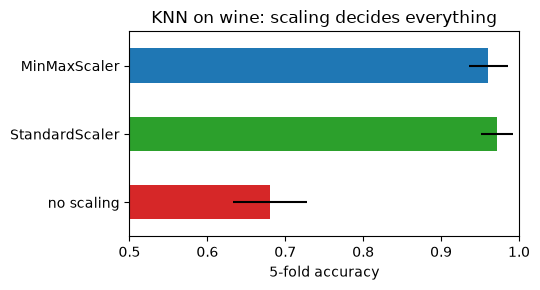

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 3))
scaling_scores.mean().plot.barh(ax=ax, xerr=scaling_scores.std(), color=["tab:red", "tab:green", "tab:blue"])
ax.set(xlabel="5-fold accuracy", title="KNN on wine: scaling decides everything", xlim=(0.5, 1.0))
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Three people are stored as `[height in cm, weight in grams]`. Standardize the columns (mean 0, standard deviation 1, using `people`'s own statistics) and find the index of the person **nearest to `query_person`** after scaling. Store it in `scaled_nearest`. (Before scaling the answer is person 0, because grams swamp centimetres.)

In [14]:
people = np.array([[160.0, 72000.0],
                   [185.0, 70500.0],
                   [172.0, 71000.0]])
query_person = np.array([183.0, 71800.0])
raw_nearest = int(np.argmin(np.linalg.norm(people - query_person, axis=1)))
print("raw nearest person:", raw_nearest)
scaled_nearest = None  # TODO: your code here
check("scaled_nearest", scaled_nearest, 2, hint="mu, sd = people.mean(axis=0), people.std(axis=0); scale BOTH people and query.")

raw nearest person: 0
⏳ scaled_nearest: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
people = np.array([[160.0, 72000.0], [185.0, 70500.0], [172.0, 71000.0]])
query_person = np.array([183.0, 71800.0])
mu, sd = people.mean(axis=0), people.std(axis=0)
scaled_nearest = int(np.argmin(np.linalg.norm((people - mu) / sd - (query_person - mu) / sd, axis=1)))
check("scaled_nearest", scaled_nearest, 2)
```

Once both features count equally, person 2 (172 cm, 71 kg) is closest. Always apply the **same** training statistics to the query.
</details>

> 💡 **Interview angle:** "Does KNN need feature scaling? Does a decision tree?" — KNN yes (distances add raw units; we measured proline taking most of the distance), trees no (splits compare one feature at a time). Put the scaler inside a `Pipeline` so cross-validation doesn't leak test statistics.

## 4. Choosing k: Bias, Variance and Decision Boundaries 🟡

- **k = 1**: every training point claims its own little island. Training accuracy is 100%, the boundary is jagged, and one mislabelled point changes predictions around it → **low bias, high variance** (overfitting).
- **Large k**: many neighbours vote, the boundary becomes smooth, and at $k = n$ every prediction is simply the majority class → **high bias, low variance** (underfitting).

For KNN regression this trade-off has an exact formula. If $y = f(x) + \varepsilon$ with noise variance $\sigma^2$ and we treat the training inputs as fixed, the expected error at a point $x_0$ is

$$\mathbb{E}\big[(y_0 - \hat f_k(x_0))^2\big] = \underbrace{\sigma^2}_{\text{irreducible}} + \underbrace{\Big(f(x_0) - \tfrac{1}{k}\textstyle\sum_{i \in N_k(x_0)} f(x_i)\Big)^2}_{\text{bias}^2\text{ grows with } k} + \underbrace{\sigma^2 / k}_{\text{variance shrinks with } k}$$

Averaging more neighbours cancels noise (variance $\sigma^2/k$), but those neighbours are farther away and less similar (bias). The "effective number of parameters" of KNN is roughly $n/k$, so **larger k = simpler model**.

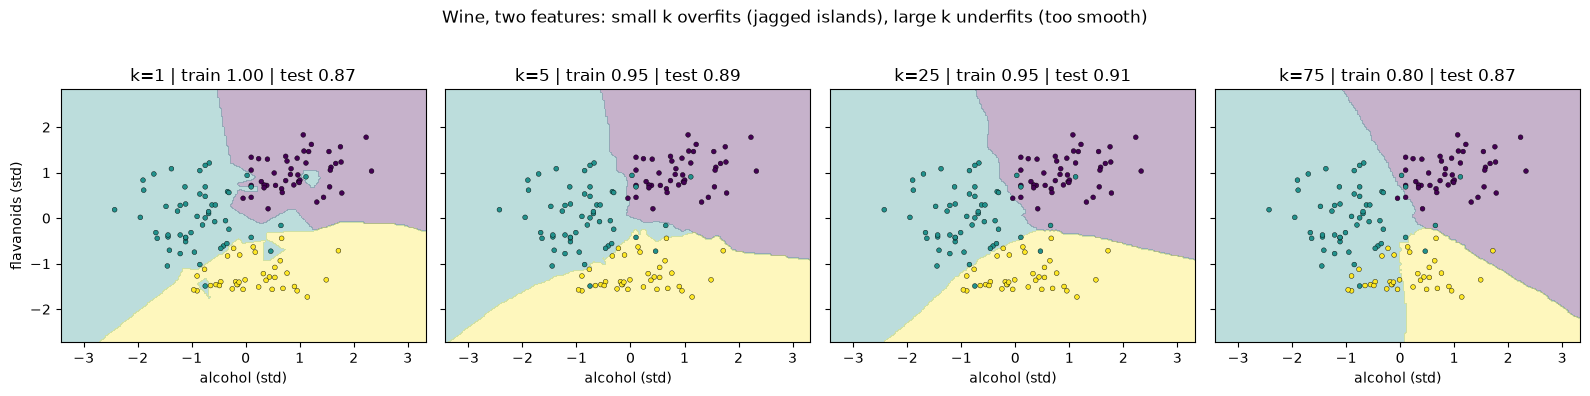

In [15]:
boundary_ks = [1, 5, 25, 75]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
for ax, k in zip(axes, boundary_ks):
    model = KNeighborsClassifier(n_neighbors=k).fit(Z2_tr, y2_tr)
    display = DecisionBoundaryDisplay.from_estimator(model, Z2_tr, response_method="predict", alpha=0.3, ax=ax,
                                                     grid_resolution=200, multiclass_colors="viridis")
    ax.scatter(*Z2_tr.T, c=y2_tr, s=12, edgecolor="k", linewidth=0.3, cmap=ListedColormap(display.multiclass_colors_))
    ax.set(title=f"k={k} | train {model.score(Z2_tr, y2_tr):.2f} | test {model.score(Z2_te, y2_te):.2f}",
           xlabel="alcohol (std)")
axes[0].set_ylabel("flavanoids (std)")
plt.suptitle("Wine, two features: small k overfits (jagged islands), large k underfits (too smooth)", y=1.03)
plt.tight_layout()
plt.show()

The pictures use a single train/test split. To actually **choose** k, use cross-validation on training data. `validation_curve` scores each k on the same folds and returns both the training and the validation scores, so we can see over- and underfitting.

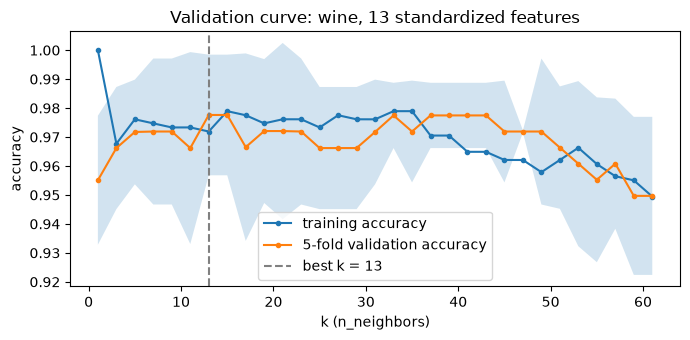

best k = 13 (accuracy 0.978 ± 0.021) | one-standard-error rule picks k = 49 | k=1 training accuracy = 1.000


In [16]:
k_grid = np.arange(1, 62, 2)
wine_pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())
train_scores, val_scores = validation_curve(wine_pipe, X_wine, y_wine, param_name="kneighborsclassifier__n_neighbors",
                                            param_range=k_grid, cv=wine_folds)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)
best_i = int(val_mean.argmax())
se = val_std[best_i] / np.sqrt(val_scores.shape[1])
one_se_k = int(k_grid[val_mean >= val_mean[best_i] - se].max())     # largest (simplest) k within 1 SE of the best

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(k_grid, train_scores.mean(axis=1), "o-", ms=3, label="training accuracy")
ax.plot(k_grid, val_mean, "o-", ms=3, label="5-fold validation accuracy")
ax.fill_between(k_grid, val_mean - val_std, val_mean + val_std, alpha=0.2)
ax.axvline(k_grid[best_i], ls="--", c="grey", label=f"best k = {k_grid[best_i]}")
ax.set(xlabel="k (n_neighbors)", ylabel="accuracy", title="Validation curve: wine, 13 standardized features")
ax.legend()
plt.tight_layout()
plt.show()
print(f"best k = {k_grid[best_i]} (accuracy {val_mean[best_i]:.3f} ± {val_std[best_i]:.3f}) | "
      f"one-standard-error rule picks k = {one_se_k} | k=1 training accuracy = {train_scores[0].mean():.3f}")

**Rules of thumb:** search odd values of k from 1 to about $\sqrt{n}$ with cross-validation; prefer odd k for binary problems to avoid tied votes; when several k are within noise of each other, prefer the **larger** k (the simpler, smoother model).

### ✍️ Your Turn

Apply the **one-standard-error rule** to these 5-fold CV results: find the best mean score, compute its standard error `std / sqrt(5)`, then return the **largest** k whose mean score is at least `best − SE`.

In [17]:
cv_k = np.array([1, 3, 5, 7, 9, 11])
cv_mean = np.array([0.90, 0.93, 0.95, 0.96, 0.955, 0.94])
cv_std = np.array([0.03, 0.02, 0.02, 0.02, 0.02, 0.03])
chosen_k = None  # TODO: your code here
check("chosen_k", chosen_k, 9, hint="best = cv_mean.argmax(); threshold = cv_mean[best] - cv_std[best] / np.sqrt(5); take the max k above it.")

⏳ chosen_k: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
cv_k = np.array([1, 3, 5, 7, 9, 11])
cv_mean = np.array([0.90, 0.93, 0.95, 0.96, 0.955, 0.94])
cv_std = np.array([0.03, 0.02, 0.02, 0.02, 0.02, 0.03])
best = cv_mean.argmax()
threshold = cv_mean[best] - cv_std[best] / np.sqrt(5)
chosen_k = int(cv_k[cv_mean >= threshold].max())
check("chosen_k", chosen_k, 9)
```

The best is k=7 (0.96) with SE ≈ 0.0089, so anything ≥ 0.9511 is "as good": k=7 and k=9. For KNN the **larger** k is the simpler model, so pick 9.
</details>

> 💡 **Interview angle:** "How do you choose k?" — cross-validate a grid of (odd) values inside a pipeline with scaling; small k = low bias/high variance, large k = high bias/low variance; pick the best or the simplest within one standard error; never pick k on the test set, and never judge k=1 by training accuracy (it's always ~100%).

## 5. Uniform vs Distance Weights 🟡

With `weights="uniform"` each of the k neighbours gets one vote. With `weights="distance"` a neighbour at distance $d_i$ gets weight $w_i = 1/d_i$:

$$\hat y(x) = \arg\max_c \sum_{i \in N_k(x)} w_i\, \mathbb{1}[y_i = c] \qquad\qquad \hat y_{\text{reg}}(x) = \frac{\sum_i w_i\, y_i}{\sum_i w_i}$$

Closer neighbours count more, so a large k hurts less. One edge case: if the query sits **exactly** on a training point ($d = 0$), scikit-learn gives the zero-distance point(s) weight 1 and every other neighbour weight 0. That's why training accuracy with distance weights is always 100% (each training point finds itself).

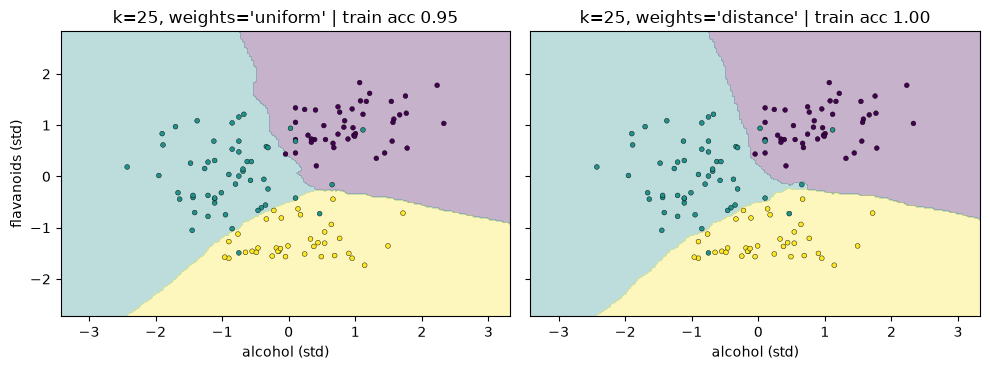

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, weights in zip(axes, ["uniform", "distance"]):
    model = KNeighborsClassifier(n_neighbors=25, weights=weights).fit(Z2_tr, y2_tr)
    display = DecisionBoundaryDisplay.from_estimator(model, Z2_tr, response_method="predict", alpha=0.3, ax=ax,
                                                     grid_resolution=200, multiclass_colors="viridis")
    ax.scatter(*Z2_tr.T, c=y2_tr, s=12, edgecolor="k", linewidth=0.3, cmap=ListedColormap(display.multiclass_colors_))
    ax.set(title=f"k=25, weights='{weights}' | train acc {model.score(Z2_tr, y2_tr):.2f}", xlabel="alcohol (std)")
axes[0].set_ylabel("flavanoids (std)")
plt.tight_layout()
plt.show()

In [19]:
weight_rows = []
for k in [1, 5, 15, 31, 61]:
    for weights in ["uniform", "distance"]:
        pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k, weights=weights))
        weight_rows.append({"k": k, "weights": weights,
                            "wine CV acc": cross_val_score(pipe, X_wine, y_wine, cv=wine_folds).mean(),
                            "digits CV acc": cross_val_score(KNeighborsClassifier(n_neighbors=k, weights=weights),
                                                             digits.data, digits.target, cv=digit_folds).mean()})
weight_table = pd.DataFrame(weight_rows).pivot(index="k", columns="weights")
print(weight_table.round(3))
drop_uniform = weight_table[("digits CV acc", "uniform")].iloc[0] - weight_table[("digits CV acc", "uniform")].iloc[-1]
drop_distance = weight_table[("digits CV acc", "distance")].iloc[0] - weight_table[("digits CV acc", "distance")].iloc[-1]
print(f"\ndigits: going from k=1 to k=61 costs {drop_uniform:.3f} accuracy with uniform weights "
      f"but {drop_distance:.3f} with distance weights → distance weighting "
      f"{'makes large k less harmful' if drop_distance < drop_uniform else 'did not help here'}.")

        wine CV acc         digits CV acc        
weights    distance uniform      distance uniform
k                                                
1             0.955   0.955         0.988   0.988
5             0.972   0.972         0.987   0.987
15            0.978   0.978         0.981   0.976
31            0.972   0.972         0.969   0.966
61            0.966   0.950         0.957   0.939

digits: going from k=1 to k=61 costs 0.050 accuracy with uniform weights but 0.031 with distance weights → distance weighting makes large k less harmful.


> 💡 **Interview angle:** "Uniform or distance weights?" — treat it as a hyperparameter and cross-validate both. Distance weights make results less sensitive to k and help when neighbourhoods are uneven, but they amplify noise from a single very close mislabelled point, and the zero-distance rule means training accuracy is meaningless.

## 6. The Math: KNN as a Local Probability Estimate 🟡

The best possible classifier (the **Bayes classifier**) predicts $\arg\max_c P(y=c \mid x)$. KNN estimates that probability directly from the neighbourhood:

$$\hat P(y = c \mid x) = \frac{k_c}{k}, \quad k_c = \text{number of the k neighbours with label } c$$

That's exactly what `predict_proba` returns with uniform weights. Two consequences:

1. **Coarse probabilities.** With k=5 the only possible values are 0, 0.2, 0.4, 0.6, 0.8, 1. Small k gives jumpy, overconfident probabilities (log loss punishes 0 and 1 hard); larger k gives smoother estimates.
2. **A famous guarantee (Cover & Hart, 1967).** As the training set grows, the error of **1-NN** is at most **twice the Bayes error**, and k-NN with $k \to \infty$, $k/n \to 0$ converges to the Bayes classifier. KNN is *consistent*: with enough data it learns any boundary — the catch is how much data "enough" is in high dimensions (Section 7).

**Complexity to remember:** brute-force prediction computes n distances of d features for each query, O(n·d), plus O(n) to select the k smallest (`argpartition`), not O(n log n) sorting.

In [20]:
Xm = mammo.data.to_numpy()
ym = (mammo.target == "1").to_numpy().astype(int)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.25, stratify=ym, random_state=SEED)

proba_rows = []
for k in [5, 25, 101]:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(Xm_tr, ym_tr)
    p = pipe.predict_proba(Xm_te)[:, 1]
    proba_rows.append({"k": k, "distinct probability values": len(np.unique(p)),
                       "log loss": log_loss(ym_te, np.clip(p, 1e-15, 1 - 1e-15)),
                       "share predicted exactly 0": (p == 0).mean()})
print(pd.DataFrame(proba_rows).set_index("k").round(4))
print("\nWith k=5, the probability values are:", np.unique(make_pipeline(StandardScaler(), KNeighborsClassifier(5))
                                                         .fit(Xm_tr, ym_tr).predict_proba(Xm_te)[:, 1]))

     distinct probability values  log loss  share predicted exactly 0
k                                                                    
5                              6    0.1819                     0.9531
25                            26    0.0939                     0.8823
101                           56    0.0538                     0.4077

With k=5, the probability values are: [0.  0.2 0.4 0.6 0.8 1. ]


> 💡 **Interview angle:** "Is KNN's `predict_proba` a good probability?" — it's the fraction of neighbours per class: coarse (multiples of 1/k), overconfident for small k (many exact 0s and 1s → terrible log loss). Use larger k, distance weights, or calibrate on held-out data if probabilities matter.

## 7. The Curse of Dimensionality 🔴

KNN assumes "near" means "similar". In many dimensions that assumption quietly dies:

- **Distances concentrate.** The nearest and the farthest points end up at almost the same distance, so "nearest" carries little information.
- **Neighbourhoods stop being local.** To capture a fraction $f$ of uniformly spread data inside a small cube, the cube's edge must be $e = f^{1/d}$. In 10 dimensions, grabbing 10% of the data needs a cube spanning ~80% of every feature's range.
- **Data needed explodes.** Keeping the same density of points needs a number of samples that grows exponentially with d.

We *measure* distance concentration with **relative contrast** $\frac{d_{\max} - d_{\min}}{d_{\min}}$ from each query to 2,000 points. This part uses uniformly random points on purpose: a controlled experiment where only the dimension changes.

            relative contrast (max-min)/min  nearest / farthest  \
dimensions                                                        
1                                 58770.716               0.000   
2                                   125.168               0.011   
5                                     9.233               0.105   
10                                    3.196               0.242   
50                                    0.751               0.572   
100                                   0.467               0.682   
500                                   0.183               0.845   
1000                                  0.127               0.887   

            std / mean of distances  
dimensions                           
1                             0.659  
2                             0.443  
5                             0.262  
10                            0.180  
50                            0.079  
100                           0.055  
500                      

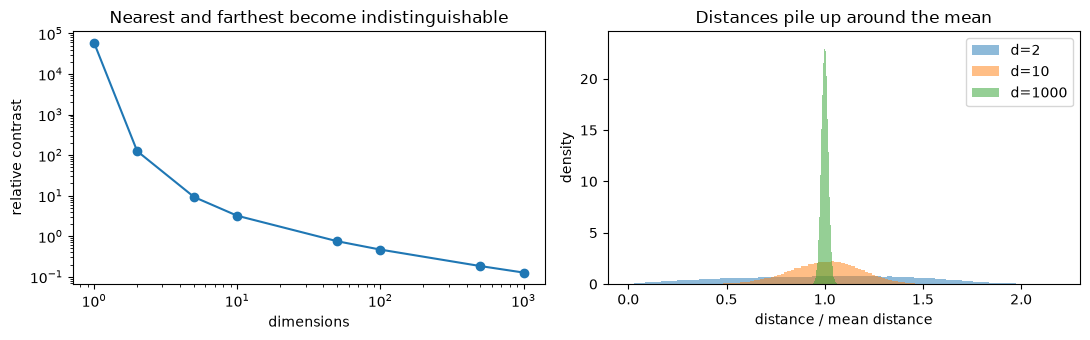

In [21]:
dims = [1, 2, 5, 10, 50, 100, 500, 1000]
concentration_rows = []
distance_samples = {}
for d in dims:
    points, queries = rng.random((2000, d)), rng.random((100, d))
    D = pairwise_distances(queries, points)
    concentration_rows.append({"dimensions": d,
                               "relative contrast (max-min)/min": ((D.max(1) - D.min(1)) / D.min(1)).mean(),
                               "nearest / farthest": (D.min(1) / D.max(1)).mean(),
                               "std / mean of distances": (D.std(1) / D.mean(1)).mean()})
    distance_samples[d] = (D / D.mean(axis=1, keepdims=True)).ravel()
concentration = pd.DataFrame(concentration_rows).set_index("dimensions")
print(concentration.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].loglog(concentration.index, concentration.iloc[:, 0], "o-")
axes[0].set(xlabel="dimensions", ylabel="relative contrast", title="Nearest and farthest become indistinguishable")
for d in [2, 10, 1000]:
    axes[1].hist(distance_samples[d], bins=80, alpha=0.5, density=True, label=f"d={d}")
axes[1].set(xlabel="distance / mean distance", ylabel="density", title="Distances pile up around the mean")
axes[1].legend()
plt.tight_layout()
plt.show()

**Real data is kinder.** Real features are correlated and lie near a lower-dimensional surface (a *manifold*), so their *intrinsic* dimension is far below the column count. Compare the 64-pixel digits with 64-dimensional uniform noise of the same size, and count how many PCA components hold 90% of the digits' variance.

In [22]:
def mean_relative_contrast(X, n_queries=100):
    idx = rng.choice(len(X), size=n_queries, replace=False)
    D = pairwise_distances(X[idx], X)
    D[np.arange(n_queries), idx] = np.inf                   # ignore each query's distance to itself
    d_min = D.min(axis=1)
    D[np.arange(n_queries), idx] = -np.inf
    return ((D.max(axis=1) - d_min) / d_min).mean()

noise_64 = rng.random(digits.data.shape)
pca_90 = int(np.searchsorted(np.cumsum(PCA().fit(digits.data).explained_variance_ratio_), 0.90) + 1)
print(f"relative contrast — digits (64 pixels): {mean_relative_contrast(digits.data):.2f} | "
      f"uniform noise (64 dims): {mean_relative_contrast(noise_64):.2f}")
print(f"PCA components needed for 90% of digit variance: {pca_90} of 64 → the intrinsic dimension is much lower")

relative contrast — digits (64 pixels): 3.18 | uniform noise (64 dims): 0.62
PCA components needed for 90% of digit variance: 21 of 64 → the intrinsic dimension is much lower


### ✍️ Your Turn

Data is spread uniformly in a unit hypercube with `d = 10` features. What **edge length** must a small cube have to contain 10% of the data (`f = 0.1`)? Store it in `edge`.

In [23]:
d, f = 10, 0.1
edge = None  # TODO: your code here
check("edge", edge, 0.7943282, hint="Volume = edge ** d must equal f, so edge = f ** (1 / d).")

⏳ edge: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
d, f = 10, 0.1
edge = f ** (1 / d)
check("edge", edge, 0.7943282)
```

A "neighbourhood" holding just 10% of the data spans 79% of every feature's range: it isn't local any more. In 100 dimensions the edge is 0.977.
</details>

> 💡 **Interview angle:** "What is the curse of dimensionality and how do you fight it for KNN?" — in high dimensions distances concentrate and neighbourhoods stop being local, so you need exponentially more data. Fight it with feature selection, dimensionality reduction (PCA, learned embeddings), metric learning, or a model that doesn't rely on raw distances. Mention that real data has a lower intrinsic dimension, which is why KNN on good embeddings still works.

## 8. Assumptions and When They Break 🟡

KNN quietly assumes:

1. **Every feature is relevant and on a comparable scale** (Section 3 broke the scale part).
2. **Locality:** points that are close have similar labels.
3. **Enough data to fill the space** (Section 7).

Let's break assumption 1 with an experiment. We append columns of pure random noise to the real wine features (a controlled test: the extra columns carry no information) and watch KNN compared with logistic regression, which can learn to give noise columns a weight near zero. Then we fix KNN with feature selection *inside* the pipeline.

In [24]:
noise_rows = []
for n_noise in [0, 10, 50, 200]:
    X_noisy = np.hstack([X_wine.to_numpy(), rng.normal(size=(len(X_wine), n_noise))])
    models = {
        "KNN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
        "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
        "KNN + SelectKBest(13)": make_pipeline(StandardScaler(),
                                                SelectKBest(partial(mutual_info_classif, random_state=SEED), k=13),
                                                KNeighborsClassifier(n_neighbors=5)),
    }
    row = {"noise columns": n_noise}
    for name, model in models.items():
        row[name] = cross_val_score(model, X_noisy, y_wine, cv=wine_folds).mean()
    noise_rows.append(row)
noise_table = pd.DataFrame(noise_rows).set_index("noise columns")
print(noise_table.round(3))
knn_drop = noise_table["KNN (k=5)"].iloc[0] - noise_table["KNN (k=5)"].iloc[-1]
lr_drop = noise_table["logistic regression"].iloc[0] - noise_table["logistic regression"].iloc[-1]
sel_drop = noise_table["KNN + SelectKBest(13)"].iloc[0] - noise_table["KNN + SelectKBest(13)"].iloc[-1]
print(f"\nWith 200 noise columns accuracy drops by: KNN {knn_drop:.3f} | logistic regression {lr_drop:.3f} | "
      f"KNN with feature selection {sel_drop:.3f}")

               KNN (k=5)  logistic regression  KNN + SelectKBest(13)
noise columns                                                       
0                  0.972                0.983                  0.972
10                 0.927                0.966                  0.977
50                 0.888                0.966                  0.966
200                0.759                0.938                  0.961

With 200 noise columns accuracy drops by: KNN 0.213 | logistic regression 0.046 | KNN with feature selection 0.011


Every noise column adds random amounts to every distance, drowning the 13 useful ones. Logistic regression degrades much less because it *learns* per-feature weights. Selecting features inside the pipeline recovers most of KNN's accuracy.

> 💡 **Interview angle:** "KNN performs badly on a dataset with 500 features. Why, and what do you do?" — irrelevant features add noise to every distance and dimensions concentrate distances. Scale, remove or select features (inside CV), reduce with PCA or embeddings, or try a model that learns feature weights.

## 9. Brute Force, KD-Tree and Ball Tree 🔴

Finding neighbours is the expensive part, and scikit-learn has three exact strategies (`algorithm=`):

| Algorithm | How it works | Build | Query (per point) | Best when |
|---|---|---|---|---|
| `brute` | compute every distance, using fast matrix maths | none | O(n·d) | high d, small n, sparse data, any metric |
| `kd_tree` | recursively split space along one feature at the median, like a binary search in d dimensions; skip boxes that can't contain a closer point | O(d·n log n) | ≈ O(log n) for small d, → O(n) as d grows | low d (≲ 15–20) |
| `ball_tree` | nest points into hyperspheres (balls); prune a ball if even its closest edge is too far | O(d·n log n) | similar, degrades more gracefully with d; supports more metrics | moderate d, non-Euclidean metrics |

`algorithm="auto"` (the default) chooses brute force when there are more than 15 features, when k ≥ n/2, or for metrics the trees don't support; otherwise a KD-tree. Let's measure on controlled uniform data (the worst case for trees, since it has no clusters to exploit).

In [25]:
def time_neighbours(algorithm, X_db, X_query, k=5):
    nn = NearestNeighbors(n_neighbors=k, algorithm=algorithm)
    start = time.perf_counter(); nn.fit(X_db); fit_s = time.perf_counter() - start
    start = time.perf_counter(); nn.kneighbors(X_query); query_s = time.perf_counter() - start
    return fit_s, query_s

algorithms = ["brute", "kd_tree", "ball_tree"]
rows_n = []
for n in [10_000, 100_000, 400_000]:
    X_db, X_q = rng.random((n, 3)), rng.random((2000, 3))
    for algorithm in algorithms:
        fit_s, query_s = time_neighbours(algorithm, X_db, X_q)
        rows_n.append({"n": n, "algorithm": algorithm, "fit ms": fit_s * 1000, "query ms (2,000 queries)": query_s * 1000})
rows_d = []
for d in [2, 8, 16, 32, 64]:
    X_db, X_q = rng.random((50_000, d)), rng.random((1000, d))
    for algorithm in algorithms:
        fit_s, query_s = time_neighbours(algorithm, X_db, X_q)
        rows_d.append({"d": d, "algorithm": algorithm, "fit ms": fit_s * 1000, "query ms (1,000 queries)": query_s * 1000})
del X_db, X_q
by_n = pd.DataFrame(rows_n).pivot(index="n", columns="algorithm")
by_d = pd.DataFrame(rows_d).pivot(index="d", columns="algorithm")
print("Growing n (d = 3):\n", by_n.round(1), "\n\nGrowing d (n = 50,000):\n", by_d.round(1))

Growing n (d = 3):
              fit ms               query ms (2,000 queries)               
algorithm ball_tree brute kd_tree                ball_tree  brute kd_tree
n                                                                        
10000           1.3   0.1     1.5                      4.1    8.0     2.4
100000         15.5   0.2    15.1                      7.0   35.4     2.8
400000         73.8   0.3    71.6                     11.8  103.7     4.6 

Growing d (n = 50,000):
              fit ms               query ms (1,000 queries)              
algorithm ball_tree brute kd_tree                ball_tree brute kd_tree
d                                                                       
2               6.2   0.1     6.3                      1.7   7.9     1.0
8               9.4   0.1     9.5                     32.9   9.0    15.0
16             12.7   0.2    12.6                    215.7  10.5   276.4
32             22.5   0.3    23.8                    485.4  14.4   685.

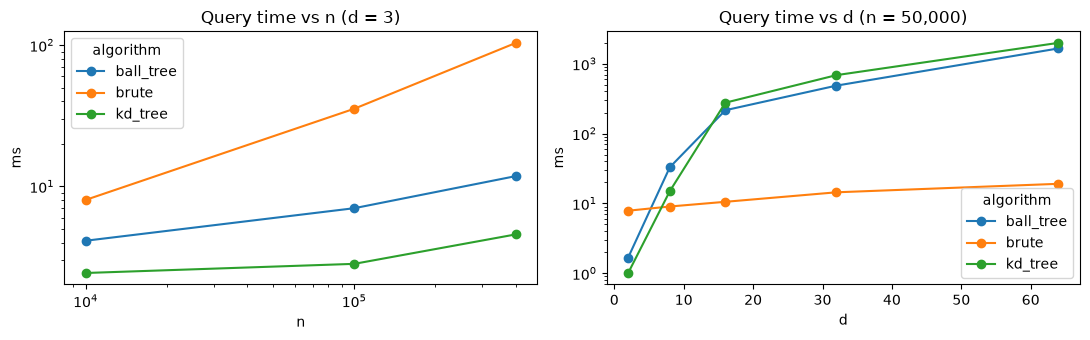

d=3, n=400k: kd_tree queries are 22.7× faster than brute force
d=64, n=50k: kd_tree queries are 104.3× slower than brute force
auto picks: d=3 → kd_tree, d=64 → brute


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
by_n["query ms (2,000 queries)"].plot(ax=axes[0], marker="o", logx=True, logy=True,
                                      title="Query time vs n (d = 3)", ylabel="ms")
by_d["query ms (1,000 queries)"].plot(ax=axes[1], marker="o", logy=True, title="Query time vs d (n = 50,000)", ylabel="ms")
plt.tight_layout()
plt.show()

q_n, q_d = by_n["query ms (2,000 queries)"], by_d["query ms (1,000 queries)"]
print(f"d=3, n=400k: kd_tree queries are {q_n.loc[400_000, 'brute'] / q_n.loc[400_000, 'kd_tree']:.1f}× "
      f"{'faster' if q_n.loc[400_000, 'kd_tree'] < q_n.loc[400_000, 'brute'] else 'slower'} than brute force")
print(f"d=64, n=50k: kd_tree queries are {q_d.loc[64, 'kd_tree'] / q_d.loc[64, 'brute']:.1f}× "
      f"{'slower' if q_d.loc[64, 'kd_tree'] > q_d.loc[64, 'brute'] else 'faster'} than brute force")
print(f"auto picks: d=3 → {NearestNeighbors().fit(rng.random((1000, 3)))._fit_method}, "
      f"d=64 → {NearestNeighbors().fit(rng.random((1000, 64)))._fit_method}")

Timings depend on your CPU (brute force runs its distance kernels on all cores), but the shape is robust: **trees win in low dimensions, brute force wins in high dimensions**, and every exact method still touches a large part of the data for each query when d is large. That is what approximate methods (Section 12) fix.

> 💡 **Interview angle:** "KD-tree vs ball tree vs brute force?" — KD-trees split on coordinate axes and prune boxes: great for d ≲ 20. Ball trees use hyperspheres, handle more metrics and higher d a bit better. In high dimensions pruning fails (curse of dimensionality) and vectorized brute force wins; beyond that you go approximate (HNSW, IVF-PQ).

## 10. KNN Regression 🟢

For regression, KNN predicts the (weighted) **average** of the neighbours' targets. A natural real example: the value of a California house is well predicted by the prices of houses **physically nearby**, i.e. neighbours in latitude/longitude. A straight line through latitude and longitude can't capture coastal cities; KNN can.

In [27]:
geo_cols = ["Latitude", "Longitude"]
X_geo, y_geo = housing.data[geo_cols].to_numpy(), housing.target.to_numpy()
geo_folds = KFold(n_splits=5, shuffle=True, random_state=SEED)
geo_rows = [{"model": "LinearRegression", "CV R²": cross_val_score(LinearRegression(), X_geo, y_geo, cv=geo_folds, scoring="r2").mean()}]
for k in [1, 5, 15, 50, 200]:
    for weights in ["uniform", "distance"]:
        model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k, weights=weights))
        geo_rows.append({"model": f"KNN k={k}, {weights}",
                         "CV R²": cross_val_score(model, X_geo, y_geo, cv=geo_folds, scoring="r2").mean()})
geo_table = pd.DataFrame(geo_rows).set_index("model").sort_values("CV R²", ascending=False)
print(geo_table.round(3))
print(f"\nBest: {geo_table.index[0]} (R² {geo_table.iloc[0, 0]:.3f}) vs linear regression "
      f"(R² {geo_table.loc['LinearRegression', 'CV R²']:.3f}) using only two coordinates.")

                     CV R²
model                     
KNN k=5, uniform     0.788
KNN k=15, uniform    0.777
KNN k=5, distance    0.775
KNN k=15, distance   0.772
KNN k=50, distance   0.754
KNN k=200, distance  0.722
KNN k=50, uniform    0.715
KNN k=1, uniform     0.695
KNN k=1, distance    0.695
KNN k=200, uniform   0.607
LinearRegression     0.242

Best: KNN k=5, uniform (R² 0.788) vs linear regression (R² 0.242) using only two coordinates.


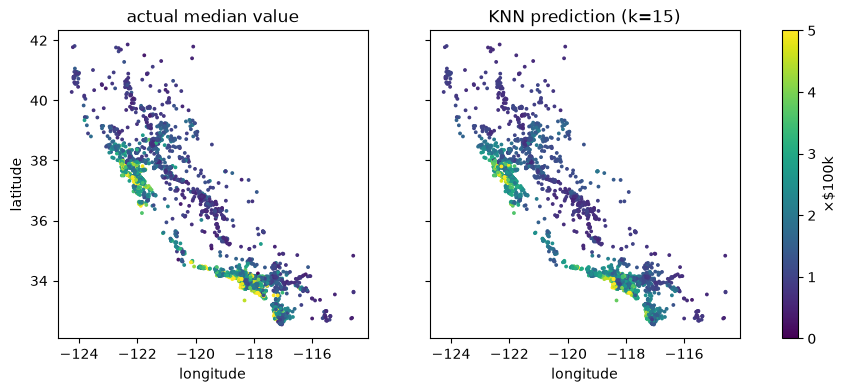

In [28]:
Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(X_geo, y_geo, test_size=0.25, random_state=SEED)
best_geo = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=15, weights="distance")).fit(Xg_tr, yg_tr)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, values, title in [(axes[0], yg_te, "actual median value"), (axes[1], best_geo.predict(Xg_te), "KNN prediction (k=15)")]:
    sc = ax.scatter(Xg_te[:, 1], Xg_te[:, 0], c=values, s=3, cmap="viridis", vmin=0, vmax=5)
    ax.set(title=title, xlabel="longitude")
axes[0].set_ylabel("latitude")
fig.colorbar(sc, ax=axes, label="×$100k")
plt.show()

### ✍️ Your Turn

A query's 3 neighbours have targets `[2.0, 3.0, 4.0]` at distances `[1.0, 2.0, 4.0]`. Compute the **distance-weighted** KNN regression prediction `weighted_pred` ($w_i = 1/d_i$).

In [29]:
nbr_targets = np.array([2.0, 3.0, 4.0])
nbr_dists = np.array([1.0, 2.0, 4.0])
weighted_pred = None  # TODO: your code here
check("weighted_pred", weighted_pred, 2.5714286, hint="w = 1 / nbr_dists; prediction = (w * targets).sum() / w.sum().")

⏳ weighted_pred: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
nbr_targets = np.array([2.0, 3.0, 4.0])
nbr_dists = np.array([1.0, 2.0, 4.0])
w = 1 / nbr_dists
weighted_pred = (w * nbr_targets).sum() / w.sum()
check("weighted_pred", weighted_pred, 2.5714286)
```

Weights are 1, 0.5, 0.25, so the closest neighbour's 2.0 pulls the answer below the uniform mean of 3.0.
</details>

> 💡 **Interview angle:** "Can KNN extrapolate?" — no. A KNN regressor's prediction is a weighted average of training targets, so it can never predict outside the range of targets it has seen (unlike linear regression). Great for smooth local patterns like geography, poor for trends that continue beyond the data.

## 11. KNN With Imbalanced Classes 🟡

In the **mammography** dataset only about 2% of cases are malignant. With a majority vote, the rare class almost never wins a neighbourhood, so KNN predicts "benign" nearly everywhere and still reports excellent accuracy.

KNN has no `class_weight` option. The practical fixes are:

- **Lower the decision threshold** on `predict_proba` (predict positive if ≥ 1 of k neighbours is positive, say), tuned by cross-validation with `TunedThresholdClassifierCV`.
- **Resample the training folds** with imbalanced-learn (e.g. `SMOTE` creates synthetic minority points between real minority neighbours — itself a KNN idea). Resampling must happen **inside** the pipeline so validation folds stay untouched.

We compare on the same folds, with metrics that respect the rare class: recall, precision, F1, balanced accuracy and average precision (PR-AUC).

In [30]:
imb_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
imb_models = {
    "KNN k=5 (default threshold 0.5)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "KNN k=15 distance + tuned threshold": TunedThresholdClassifierCV(
        make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15, weights="distance")),
        scoring="f1", cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)),
    "SMOTE + KNN k=5 (imblearn pipeline)": make_imb_pipeline(StandardScaler(), SMOTE(random_state=SEED),
                                                             KNeighborsClassifier(n_neighbors=5)),
}
scoring = ["accuracy", "balanced_accuracy", "recall", "precision", "f1", "average_precision"]
imb_rows = {}
for name, model in imb_models.items():
    res = cross_validate(model, Xm_tr, ym_tr, cv=imb_folds, scoring=scoring)
    imb_rows[name] = {m: res[f"test_{m}"].mean() for m in scoring}
imb_table = pd.DataFrame(imb_rows).T
print(f"majority-class baseline accuracy: {1 - ym_tr.mean():.3f}\n")
print(imb_table.round(3))
default_name = "KNN k=5 (default threshold 0.5)"
best_f1 = imb_table["f1"].idxmax()
best_recall_name = imb_table["recall"].idxmax()
print(f"\nDefault KNN: accuracy {imb_table.loc[default_name, 'accuracy']:.3f} but recall only "
      f"{imb_table.loc[default_name, 'recall']:.3f}.")
print(f"Best F1: {best_f1} (recall {imb_table.loc[best_f1, 'recall']:.3f}, precision {imb_table.loc[best_f1, 'precision']:.3f}).")
print(f"Highest recall: {best_recall_name} (recall {imb_table.loc[best_recall_name, 'recall']:.3f}, "
      f"precision {imb_table.loc[best_recall_name, 'precision']:.3f}).")
print(f"Best ranking quality (average precision): {imb_table['average_precision'].idxmax()}.")

majority-class baseline accuracy: 0.977

                                     accuracy  balanced_accuracy  recall  \
KNN k=5 (default threshold 0.5)         0.986              0.765   0.533   
KNN k=15 distance + tuned threshold     0.986              0.797   0.600   
SMOTE + KNN k=5 (imblearn pipeline)     0.954              0.882   0.805   

                                     precision     f1  average_precision  
KNN k=5 (default threshold 0.5)          0.817  0.637              0.617  
KNN k=15 distance + tuned threshold      0.763  0.664              0.700  
SMOTE + KNN k=5 (imblearn pipeline)      0.314  0.452              0.411  

Default KNN: accuracy 0.986 but recall only 0.533.
Best F1: KNN k=15 distance + tuned threshold (recall 0.600, precision 0.763).
Highest recall: SMOTE + KNN k=5 (imblearn pipeline) (recall 0.805, precision 0.314).
Best ranking quality (average precision): KNN k=15 distance + tuned threshold.


**Reading the table:** each fix moves the model to a different **operating point**. Threshold tuning keeps the original data and picks the cut-off that maximizes F1. SMOTE teaches KNN that minority regions are bigger, which usually raises recall and lowers precision (more false alarms). Which one is "best" depends on the costs: in cancer screening a missed malignancy is far worse than an extra biopsy, so you might accept the lower precision; for a costly manual review queue you would not. Decide on training folds, then confirm on the test set once.

> 💡 **Interview angle:** "KNN on a 2%-positive problem has 98% accuracy. Good?" — no, that's the majority baseline. Report recall/precision/PR-AUC, tune the probability threshold with CV, or resample inside the CV pipeline (never before splitting). KNN has no class weights, so threshold and resampling are the levers.

## 12. Approximate Nearest Neighbours at Scale 🔴

Exact search costs O(n·d) per query. For a product catalogue of 100 million embeddings, that's far too slow. **Approximate nearest neighbour (ANN)** indexes trade a little **recall** (sometimes missing a true neighbour) for **orders of magnitude** faster queries:

| Family | Idea | Examples |
|---|---|---|
| **Graph-based** | link each point to its near neighbours; search by greedily walking the graph | HNSW (hnswlib, FAISS, most vector databases), NN-Descent (**pynndescent**) |
| **Inverted file / clustering** | k-means the data into cells; only search the few cells nearest the query | FAISS `IndexIVFFlat` |
| **Quantization** | compress vectors to a few bytes each (product quantization) and compare the codes | FAISS `IndexIVFPQ`, ScaNN |
| **Hashing / trees** | random projections put similar points in the same buckets or leaves | LSH, Annoy |

We use **pynndescent** (a dependency of UMAP) on 60,000 real **Fashion-MNIST** images (784 pixels each) and measure the build time, the query time and **recall@10** against exact brute force. FAISS and HNSW are covered hands-on in [Embeddings and Semantic Search](../05_NLP/02_Embeddings_and_Semantic_Search.ipynb), where the vectors come from a sentence-embedding model.

In [31]:
X_fashion, y_fashion = fetch_openml(data_id=40996, as_frame=False, return_X_y=True, data_home=DATA_HOME, parser="pandas")
X_fashion = (X_fashion / 255.0).astype(np.float32)          # pixels 0–255 → 0–1, float32 halves memory
y_fashion = y_fashion.astype(int)
gc.collect()
fashion_db, fashion_queries = X_fashion[:60_000], X_fashion[60_000:61_000]     # official train rows / test rows
print(f"database {fashion_db.shape} | queries {fashion_queries.shape} | {fashion_db.nbytes / 1e6:.0f} MB of float32")

start = time.perf_counter()
exact = NearestNeighbors(n_neighbors=10, algorithm="brute").fit(fashion_db)
exact_idx = exact.kneighbors(fashion_queries, return_distance=False)
exact_ms = (time.perf_counter() - start) * 1000

start = time.perf_counter()
pynndescent.NNDescent(fashion_db[:2000], n_neighbors=15, random_state=SEED).query(fashion_queries[:5], k=10)
warmup_s = time.perf_counter() - start                        # first call compiles numba code — not part of the index cost

start = time.perf_counter()
ann_index = pynndescent.NNDescent(fashion_db, n_neighbors=30, random_state=SEED)
ann_index.prepare()
build_s = time.perf_counter() - start
print(f"exact brute force: {exact_ms:.0f} ms for {len(fashion_queries):,} queries | "
      f"NNDescent build {build_s:.1f}s (one-time numba compile {warmup_s:.1f}s, excluded)")

ann_rows = []
for epsilon in [0.0, 0.1, 0.2]:
    start = time.perf_counter()
    ann_idx, _ = ann_index.query(fashion_queries, k=10, epsilon=epsilon)
    query_ms = (time.perf_counter() - start) * 1000
    recall = np.mean([len(set(a) & set(e)) / 10 for a, e in zip(ann_idx, exact_idx)])
    ann_rows.append({"epsilon (search effort)": epsilon, "query ms": query_ms, "recall@10": recall,
                     "speed-up vs exact": exact_ms / query_ms})
ann_table = pd.DataFrame(ann_rows).set_index("epsilon (search effort)")
print(ann_table.round(3))
best_recall = ann_table["recall@10"].max()
print(f"\nANN finds {best_recall:.1%} of the true 10 neighbours at {ann_table.loc[ann_table['recall@10'].idxmax(), 'speed-up vs exact']:.1f}× "
      f"the exact query speed (after a one-time {build_s:.0f}s build).")

database (60000, 784) | queries (1000, 784) | 188 MB of float32


exact brute force: 235 ms for 1,000 queries | NNDescent build 2.0s (one-time numba compile 7.8s, excluded)
                         query ms  recall@10  speed-up vs exact
epsilon (search effort)                                        
0.0                        42.230      0.890              5.554
0.1                        49.987      0.980              4.692
0.2                        77.500      0.997              3.026

ANN finds 99.7% of the true 10 neighbours at 3.0× the exact query speed (after a one-time 2s build).


At 60k points exact brute force is still fast on a laptop, so the speed-up is modest; the gap grows with n, because graph search visits a tiny, roughly logarithmic, fraction of the data. Bigger `epsilon` searches more of the graph (higher recall, slower). Production systems tune this recall/latency knob (HNSW's `efSearch`, IVF's `nprobe`) against a latency budget, and often **re-rank** the ANN candidates with exact distances.

**Plugging ANN into scikit-learn:** compute neighbours with any library, wrap them in a sparse graph (`KNeighborsTransformer` does this for exact search), and pass `metric="precomputed"` to `KNeighborsClassifier`, so the rest of the pipeline stays unchanged.

> 💡 **Interview angle:** "How do you serve KNN / vector search over 100M items with low latency?" — an ANN index (HNSW for high recall in RAM, IVF-PQ when memory is tight), sharded across machines, with recall@k measured against exact search on a sample, `efSearch`/`nprobe` tuned to the latency budget, exact re-ranking of the top candidates, and a plan for inserts/deletes and periodic rebuilds.

## 13. A Fair Head-to-Head Comparison 🟡

How does KNN compare with its neighbours in this series on the same real data? We use digits, **the same 5 folds** for every model, and `cross_validate`, which also reports **fit time** and **scoring (prediction) time**. Note: brute-force KNN and random forests can use several CPU cores, so treat times as indicative.

In [32]:
contenders = {
    "KNN (k=3, distance)": KNeighborsClassifier(n_neighbors=3, weights="distance"),
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "Gaussian Naive Bayes": GaussianNB(),
    "Random forest (300 trees)": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
}
h2h_rows = {}
for name, model in contenders.items():
    res = cross_validate(model, digits.data, digits.target, cv=digit_folds)
    h2h_rows[name] = {"accuracy mean": res["test_score"].mean(), "accuracy std": res["test_score"].std(),
                      "fit ms": res["fit_time"].mean() * 1000, "predict ms (360 rows)": res["score_time"].mean() * 1000}
h2h = pd.DataFrame(h2h_rows).T.sort_values("accuracy mean", ascending=False)
print(h2h.round(3))

leader, runner_up = h2h.index[:2]
gap = h2h.loc[leader, "accuracy mean"] - h2h.loc[runner_up, "accuracy mean"]
print(f"\n{leader} leads {runner_up} by {gap:.3f} accuracy "
      f"({'within' if gap < h2h['accuracy std'].max() else 'beyond'} fold-to-fold noise of {h2h['accuracy std'].max():.3f}).")
print(f"Fastest to fit: {h2h['fit ms'].idxmin()} | fastest to predict: {h2h['predict ms (360 rows)'].idxmin()} | "
      f"KNN's predict/fit time ratio: {h2h.loc['KNN (k=3, distance)', 'predict ms (360 rows)'] / h2h.loc['KNN (k=3, distance)', 'fit ms']:.0f}×")

                           accuracy mean  accuracy std   fit ms  \
KNN (k=3, distance)                0.989         0.004    0.335   
Random forest (300 trees)          0.979         0.004  171.180   
Logistic regression                0.971         0.004    5.464   
Gaussian Naive Bayes               0.845         0.018    0.612   

                           predict ms (360 rows)  
KNN (k=3, distance)                        1.776  
Random forest (300 trees)                 28.690  
Logistic regression                        0.303  
Gaussian Naive Bayes                       0.467  

KNN (k=3, distance) leads Random forest (300 trees) by 0.010 accuracy (within fold-to-fold noise of 0.018).
Fastest to fit: KNN (k=3, distance) | fastest to predict: Logistic regression | KNN's predict/fit time ratio: 5×


On small, clean, low-noise data like digits, KNN competes with the best models with essentially zero training time; its cost shows up in prediction, and it would fall behind on noisy, high-dimensional or huge datasets (Sections 7–9). Gaussian Naive Bayes is the weakest here, because its independence assumption is badly wrong for neighbouring pixels (the next notebook explains why).

> 💡 **Interview angle:** "When would you pick KNN over logistic regression or a random forest?" — small/medium data with a meaningful distance (scaled low-d features or good embeddings), irregular boundaries, need for zero training and instant updates or "similar examples" explanations. Otherwise tree ensembles and linear models are usually more robust and much faster to serve.

## 🔧 Build It From Scratch

A fully **vectorized** KNN (no Python loop over queries) with uniform and distance weights, for classification and regression. The recipe:

1. Squared distances for all pairs at once: $\lVert q - x\rVert^2 = \lVert q\rVert^2 + \lVert x\rVert^2 - 2\,q\cdot x$ → shape `(n_queries, n_train)`, clipped at 0.
2. `np.argpartition` picks the k smallest per row in O(n); then sort just those k by distance.
3. Weights: all ones, or $1/d$ with scikit-learn's rule for zero distances.
4. Classifier: add the weights per class (a one-hot trick), normalize to probabilities, `argmax`. Regressor: weighted mean.

We assert the neighbours, probabilities, predictions and regression outputs match scikit-learn (brute force) on real data. Queries include **training points themselves** so the zero-distance rule is tested too. (We use continuous features so there are no exact distance ties, whose order is arbitrary in any implementation.)

In [33]:
class ScratchKNNBase:
    def __init__(self, n_neighbors=5, weights="uniform"):
        self.n_neighbors = n_neighbors
        self.weights = weights

    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=float)
        self.y_ = np.asarray(y)
        self.sq_norms_ = (self.X_ ** 2).sum(axis=1)           # cache ‖x‖² once
        return self

    def kneighbors(self, X):
        X = np.asarray(X, dtype=float)
        sq = (X ** 2).sum(axis=1)[:, None] + self.sq_norms_[None, :] - 2 * X @ self.X_.T
        np.maximum(sq, 0, out=sq)                             # rounding can make tiny negatives
        k = self.n_neighbors
        part = np.argpartition(sq, k - 1, axis=1)[:, :k]      # k smallest per row, unordered, O(n)
        part_sq = np.take_along_axis(sq, part, axis=1)
        order = np.argsort(part_sq, axis=1, kind="stable")    # order just those k
        return np.sqrt(np.take_along_axis(part_sq, order, axis=1)), np.take_along_axis(part, order, axis=1)

    def _weights(self, dist):
        if self.weights == "uniform":
            return np.ones_like(dist)
        with np.errstate(divide="ignore"):
            w = 1.0 / dist
        exact_hit = np.isinf(w)
        rows = exact_hit.any(axis=1)
        w[rows] = exact_hit[rows]                             # zero-distance neighbours get weight 1, others 0
        return w


class ScratchKNNClassifier(ScratchKNNBase):
    def fit(self, X, y):
        super().fit(X, y)
        self.classes_, self.y_codes_ = np.unique(self.y_, return_inverse=True)
        return self

    def predict_proba(self, X):
        dist, idx = self.kneighbors(X)
        w = self._weights(dist)
        one_hot = np.eye(len(self.classes_))[self.y_codes_[idx]]   # (n_queries, k, n_classes)
        votes = (w[:, :, None] * one_hot).sum(axis=1)
        return votes / votes.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]   # argmax → lowest class on ties, like sklearn


class ScratchKNNRegressor(ScratchKNNBase):
    def predict(self, X):
        dist, idx = self.kneighbors(X)
        w = self._weights(dist)
        return (w * self.y_[idx]).sum(axis=1) / w.sum(axis=1)


# Classifier: wine, 13 standardized features; queries = test rows + 20 training rows (exact hits)
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(X_wine.to_numpy(), y_wine.to_numpy(), test_size=0.3,
                                              stratify=y_wine, random_state=SEED)
wine_scaler = StandardScaler().fit(Xw_tr)
Zw_tr, Zw_te = wine_scaler.transform(Xw_tr), wine_scaler.transform(Xw_te)
Zw_query = np.vstack([Zw_te, Zw_tr[:20]])
for k in [1, 5, 15]:
    for weights in ["uniform", "distance"]:
        ours = ScratchKNNClassifier(k, weights).fit(Zw_tr, yw_tr)
        ref = KNeighborsClassifier(n_neighbors=k, weights=weights, algorithm="brute").fit(Zw_tr, yw_tr)
        ref_dist, ref_idx = ref.kneighbors(Zw_query)
        our_dist, our_idx = ours.kneighbors(Zw_query)
        assert np.array_equal(our_idx, ref_idx) and np.allclose(our_dist, ref_dist, atol=1e-6)
        assert np.allclose(ours.predict_proba(Zw_query), ref.predict_proba(Zw_query), atol=1e-6)
        assert np.array_equal(ours.predict(Zw_query), ref.predict(Zw_query))
print(f"✅ ScratchKNNClassifier matches KNeighborsClassifier (k ∈ {{1, 5, 15}}, uniform & distance, "
      f"{len(Zw_query)} queries) | test accuracy k=5: {accuracy_score(yw_te, ScratchKNNClassifier(5).fit(Zw_tr, yw_tr).predict(Zw_te)):.3f}")

# Regressor: California housing, 8 standardized features; 5,000 training rows
Zr_tr, yr_tr = Zh_tr[:5000], yh_tr[:5000]
Zr_query = np.vstack([Zh_te[:1000], Zr_tr[:50]])
for k in [1, 10, 50]:
    for weights in ["uniform", "distance"]:
        ours = ScratchKNNRegressor(k, weights).fit(Zr_tr, yr_tr).predict(Zr_query)
        ref = KNeighborsRegressor(n_neighbors=k, weights=weights, algorithm="brute").fit(Zr_tr, yr_tr).predict(Zr_query)
        assert np.allclose(ours, ref, atol=1e-6), (k, weights)
print(f"✅ ScratchKNNRegressor matches KNeighborsRegressor (k ∈ {{1, 10, 50}}, uniform & distance, {len(Zr_query):,} queries)")

✅ ScratchKNNClassifier matches KNeighborsClassifier (k ∈ {1, 5, 15}, uniform & distance, 74 queries) | test accuracy k=5: 0.944


✅ ScratchKNNRegressor matches KNeighborsRegressor (k ∈ {1, 10, 50}, uniform & distance, 1,050 queries)


**Why the expansion trick?** Broadcasting `X[:, None, :] - X_train[None, :, :]` is simpler but allocates an `(n_queries, n_train, d)` array: 1,000 × 60,000 × 784 floats would be 376 GB. The expansion needs only `(n_queries, n_train)`. For huge training sets, also process queries in chunks (scikit-learn's `working_memory` setting does exactly that).

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Judging KNN by training accuracy

In [34]:
for k, weights in [(1, "uniform"), (15, "distance")]:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k, weights=weights)).fit(Xm_tr, ym_tr)
    print(f"❌ k={k:2d}, {weights:8s}: training accuracy {pipe.score(Xm_tr, ym_tr):.3f} (each point is its own neighbour)")
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15, weights="distance"))
print(f"✅ same model, 5-fold CV balanced accuracy: {cross_val_score(pipe, Xm_tr, ym_tr, cv=imb_folds, scoring='balanced_accuracy').mean():.3f}")

❌ k= 1, uniform : training accuracy 1.000 (each point is its own neighbour)
❌ k=15, distance: training accuracy 1.000 (each point is its own neighbour)
✅ same model, 5-fold CV balanced accuracy: 0.750


### ❌ Pitfall 2 — Even k in a binary problem: ties silently favour class 0

With k=2 and one vote each, scikit-learn picks the lowest class label. On mammography that means every tie becomes "benign".

In [35]:
scaler_m = StandardScaler().fit(Xm_tr)
knn_even = KNeighborsClassifier(n_neighbors=2).fit(scaler_m.transform(Xm_tr), ym_tr)
proba_even = knn_even.predict_proba(scaler_m.transform(Xm_te))[:, 1]
ties = proba_even == 0.5
print(f"❌ k=2: {ties.sum()} test cases are 1–1 ties, all predicted as class "
      f"{np.unique(knn_even.predict(scaler_m.transform(Xm_te))[ties])}, "
      f"though {ym_te[ties].mean():.0%} of them are actually malignant")
knn_odd = KNeighborsClassifier(n_neighbors=3).fit(scaler_m.transform(Xm_tr), ym_tr)
print(f"✅ k=3: ties impossible (votes are 0/3, 1/3, 2/3, 3/3): {np.unique(knn_odd.predict_proba(scaler_m.transform(Xm_te))[:, 1]).round(3)}")

❌ k=2: 43 test cases are 1–1 ties, all predicted as class [0], though 37% of them are actually malignant


✅ k=3: ties impossible (votes are 0/3, 1/3, 2/3, 3/3): [0.    0.333 0.667 1.   ]


### ❌ Pitfall 3 — A metric the search tree doesn't support

In [36]:
try:
    KNeighborsClassifier(metric="cosine", algorithm="kd_tree").fit(digits.data, digits.target)
except ValueError as err:
    print("❌ ValueError:", str(err)[:120])
fixed = KNeighborsClassifier(metric="cosine", algorithm="brute").fit(Xd_tr, yd_tr)
print(f"✅ cosine with brute force (or algorithm='auto'): test accuracy {fixed.score(Xd_te, yd_te):.3f}")

❌ ValueError: Metric 'cosine' not valid. Use sorted(sklearn.neighbors.VALID_METRICS['kd_tree']) to get valid options. Metric can also 
✅ cosine with brute force (or algorithm='auto'): test accuracy 0.983


### ❌ Pitfall 4 — Missing values crash KNN

In [37]:
X_missing = X_wine.to_numpy().copy()
X_missing[rng.random(X_missing.shape) < 0.05] = np.nan               # knock out 5% of the real values
try:
    make_pipeline(StandardScaler(), KNeighborsClassifier()).fit(X_missing, y_wine)
except ValueError as err:
    print("❌ ValueError:", str(err).strip().splitlines()[-1][:120])
imputed = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), KNeighborsClassifier())
print(f"✅ impute inside the pipeline: 5-fold accuracy {cross_val_score(imputed, X_missing, y_wine, cv=wine_folds).mean():.3f}")

❌ ValueError: KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to 
✅ impute inside the pipeline: 5-fold accuracy 0.949


### ❌ Pitfall 5 — Scaling the training data by hand, then predicting on raw queries

A classic train/serve skew bug: the notebook scaled the training matrix manually, but the prediction code (or the production service) passes raw, unscaled features. KNN doesn't complain; it just compares apples with oranges.

In [38]:
manual_scaler = StandardScaler().fit(Xw_tr)
knn_manual = KNeighborsClassifier(n_neighbors=5).fit(manual_scaler.transform(Xw_tr), yw_tr)
print(f"❌ trained on scaled data, queried with raw data: test accuracy {knn_manual.score(Xw_te, yw_te):.3f}")
knn_pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)).fit(Xw_tr, yw_tr)
print(f"✅ one pipeline scales training and query data identically: test accuracy {knn_pipeline.score(Xw_te, yw_te):.3f}")

❌ trained on scaled data, queried with raw data: test accuracy 0.333
✅ one pipeline scales training and query data identically: test accuracy 0.944


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Pairwise distance matrix
Compute the Euclidean distance between every row of `A` and every row of `B` as a `(2, 3)` matrix, without loops.

In [39]:
A = np.array([[0.0, 0.0], [3.0, 4.0]])
B = np.array([[0.0, 0.0], [6.0, 8.0], [3.0, 0.0]])
dist_matrix = None  # TODO
check("dist_matrix", dist_matrix, [[0.0, 10.0, 3.0], [5.0, 5.0, 4.0]],
      hint="Broadcast A[:, None, :] - B[None, :, :], square, sum over the last axis, sqrt.")

⏳ dist_matrix: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
A = np.array([[0.0, 0.0], [3.0, 4.0]])
B = np.array([[0.0, 0.0], [6.0, 8.0], [3.0, 0.0]])
dist_matrix = np.sqrt(((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=-1))
check("dist_matrix", dist_matrix, [[0.0, 10.0, 3.0], [5.0, 5.0, 4.0]])
```
For big inputs, switch to the $\lVert a\rVert^2 + \lVert b\rVert^2 - 2a\cdot b$ expansion to avoid the `(n, m, d)` temporary.
</details>

### 🟢 Exercise 2 — Votes with ties
Each row of `nbr_labels` holds the labels of 4 neighbours. Predict each row's majority label, breaking ties toward the **lowest** label (as scikit-learn does). No Python loops.

In [40]:
nbr_labels = np.array([[1, 1, 0, 0],
                       [2, 2, 2, 1],
                       [3, 1, 3, 1]])
row_votes = None  # TODO
check("row_votes", row_votes, [0, 2, 1], hint="counts = (nbr_labels[:, :, None] == np.arange(4)).sum(axis=1); then argmax(axis=1).")

⏳ row_votes: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
nbr_labels = np.array([[1, 1, 0, 0], [2, 2, 2, 1], [3, 1, 3, 1]])
counts = (nbr_labels[:, :, None] == np.arange(nbr_labels.max() + 1)).sum(axis=1)   # (rows, classes)
row_votes = counts.argmax(axis=1)
check("row_votes", row_votes, [0, 2, 1])
```
`argmax` returns the first maximum, i.e. the lowest label among tied classes.
</details>

### 🟢 Exercise 3 — Relative contrast
For one query, `dists` holds its distances to 4 points. Compute the relative contrast $(d_{\max} - d_{\min}) / d_{\min}$.

In [41]:
dists = np.array([2.0, 4.0, 5.0, 10.0])
contrast = None  # TODO
check("contrast", contrast, 4.0, hint="(dists.max() - dists.min()) / dists.min()")

⏳ contrast: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
dists = np.array([2.0, 4.0, 5.0, 10.0])
contrast = (dists.max() - dists.min()) / dists.min()
check("contrast", contrast, 4.0)
```
In Section 7 this number fell towards 0 as dimensions grew: nearest and farthest become alike.
</details>

### 🟡 Exercise 4 — Distance-weighted regression with exact hits
`nbr_d[i]` and `nbr_y[i]` are the distances and targets of query `i`'s 3 neighbours. Return the distance-weighted predictions for both queries, applying scikit-learn's rule: if a neighbour is at distance 0, only zero-distance neighbours count.

In [42]:
nbr_d = np.array([[1.0, 2.0, 4.0],
                  [0.0, 1.0, 3.0]])
nbr_y = np.array([[2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0]])
weighted_preds = None  # TODO
check("weighted_preds", weighted_preds, [2.5714286, 5.0],
      hint="w = 1/d with np.errstate(divide='ignore'); rows containing inf → replace w with (d == 0).")

⏳ weighted_preds: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
nbr_d = np.array([[1.0, 2.0, 4.0], [0.0, 1.0, 3.0]])
nbr_y = np.array([[2.0, 3.0, 4.0], [5.0, 6.0, 7.0]])
with np.errstate(divide="ignore"):
    w = 1.0 / nbr_d
hit_rows = np.isinf(w).any(axis=1)
w[hit_rows] = (nbr_d[hit_rows] == 0)
weighted_preds = (w * nbr_y).sum(axis=1) / w.sum(axis=1)
check("weighted_preds", weighted_preds, [2.5714286, 5.0])
```
Without the rule, `inf * 5 / inf` would give `nan`.
</details>

### 🟡 Exercise 5 — Hamming KNN on binary features
Five items are described by 6 yes/no attributes. Compute the **number** of differing positions between `q_bits` and each row of `bits` (`hamming_counts`), then predict `q_bits`'s label with a 3-NN majority vote (`hamming_pred`).

In [43]:
bits = np.array([[1, 0, 1, 1, 0, 0],
                 [1, 1, 1, 1, 0, 0],
                 [0, 0, 0, 1, 1, 1],
                 [0, 1, 0, 0, 1, 1],
                 [1, 0, 1, 0, 0, 0]])
bit_labels = np.array([0, 0, 1, 1, 0])
q_bits = np.array([0, 0, 1, 1, 1, 1])
hamming_counts = None  # TODO
hamming_pred = None    # TODO
check("hamming_counts", hamming_counts, [3, 4, 1, 3, 4], hint="(bits != q_bits).sum(axis=1)")
check("hamming_pred", hamming_pred, 1, hint="Take the labels of the 3 smallest counts and vote with np.bincount.")

⏳ hamming_counts: not attempted yet — replace None with your answer.
⏳ hamming_pred: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
bits = np.array([[1, 0, 1, 1, 0, 0], [1, 1, 1, 1, 0, 0], [0, 0, 0, 1, 1, 1], [0, 1, 0, 0, 1, 1], [1, 0, 1, 0, 0, 0]])
bit_labels = np.array([0, 0, 1, 1, 0])
q_bits = np.array([0, 0, 1, 1, 1, 1])
hamming_counts = (bits != q_bits).sum(axis=1)
nearest3 = np.argsort(hamming_counts, kind="stable")[:3]
hamming_pred = int(np.bincount(bit_labels[nearest3]).argmax())
check("hamming_counts", hamming_counts, [3, 4, 1, 3, 4])
check("hamming_pred", hamming_pred, 1)
```
The 3 nearest are rows 2, 0 and 3 (distances 1, 3, 3) with labels 1, 0, 1 → predict 1. scikit-learn's `metric="hamming"` returns the *fraction* (count / 6) instead, which ranks identically.
</details>

### 🔴 Exercise 6 — Vectorized KNN `predict_proba` (interview classic)
Implement `knn_predict_proba(X_train, y_train, X_query, k)` with **uniform** weights and Euclidean distance, fully vectorized (no loop over queries). Labels are integers `0..C-1`. It must match scikit-learn on real wine data.

In [44]:
def knn_predict_proba(X_train, y_train, X_query, k):
    return None  # TODO: return an (n_query, n_classes) array of neighbour-vote fractions


reference_proba = KNeighborsClassifier(n_neighbors=7, algorithm="brute").fit(Zw_tr, yw_tr).predict_proba(Zw_te)
check("knn_predict_proba", knn_predict_proba(Zw_tr, yw_tr, Zw_te, 7), reference_proba,
      hint="Squared distances via the expansion trick → argpartition(k) → one-hot the neighbour labels → mean over k.")

⏳ knn_predict_proba: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def knn_predict_proba(X_train, y_train, X_query, k):
    sq = (X_query ** 2).sum(1)[:, None] + (X_train ** 2).sum(1)[None, :] - 2 * X_query @ X_train.T
    nearest = np.argpartition(sq, k - 1, axis=1)[:, :k]               # (n_query, k), any order is fine for uniform votes
    n_classes = int(y_train.max()) + 1
    one_hot = np.eye(n_classes)[y_train[nearest]]                      # (n_query, k, n_classes)
    return one_hot.mean(axis=1)


reference_proba = KNeighborsClassifier(n_neighbors=7, algorithm="brute").fit(Zw_tr, yw_tr).predict_proba(Zw_te)
check("knn_predict_proba", knn_predict_proba(Zw_tr, yw_tr, Zw_te, 7), reference_proba)
```
Talk through the complexity: O(n_query · n_train · d) for distances, O(n_train) per row for `argpartition`, and O(n_query · n_train) memory — chunk the queries if that's too big.
</details>

## 🚀 Mini Project: Fashion-MNIST With PCA + KNN

**Goal:** classify photos of clothing (10 classes: T-shirt, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag, ankle boot) with KNN, and show how **reducing the dimension with PCA** changes both accuracy and prediction speed. Everything is tuned with cross-validation on training images; the official test images are used **once** at the end.

**Steps:** sample the data → baselines → PCA dimension sweep → grid search → one test evaluation → error analysis → computed conclusions.

### Step 1 — A laptop-sized, stratified sample

train (20000, 784) | test (4000, 784) | class counts in train: [2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000]


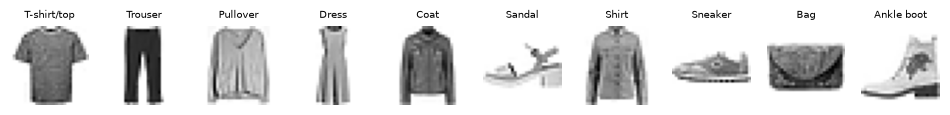

In [45]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
train_pool, test_pool = np.arange(60_000), np.arange(60_000, 70_000)    # official split: no image appears in both
proj_train, _ = train_test_split(train_pool, train_size=20_000, stratify=y_fashion[train_pool], random_state=SEED)
proj_test, _ = train_test_split(test_pool, train_size=4_000, stratify=y_fashion[test_pool], random_state=SEED)
Xf_tr, yf_tr = X_fashion[proj_train], y_fashion[proj_train]
Xf_te, yf_te = X_fashion[proj_test], y_fashion[proj_test]
del X_fashion, fashion_db, fashion_queries, ann_index, exact
gc.collect()
print(f"train {Xf_tr.shape} | test {Xf_te.shape} | class counts in train: {np.bincount(yf_tr).tolist()}")

fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for c, ax in enumerate(axes):
    ax.imshow(Xf_tr[yf_tr == c][0].reshape(28, 28), cmap="gray_r")
    ax.set_title(class_names[c], fontsize=7)
    ax.axis("off")
plt.show()

### Step 2 — Baselines (3-fold CV on the training sample)

In [46]:
proj_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
majority_acc = np.bincount(yf_tr).max() / len(yf_tr)
raw_cv = cross_validate(KNeighborsClassifier(n_neighbors=5), Xf_tr, yf_tr, cv=proj_folds)
print(f"majority class: {majority_acc:.3f} | KNN k=5 on all 784 raw pixels: {raw_cv['test_score'].mean():.3f} "
      f"(predicting a fold takes {raw_cv['score_time'].mean():.2f}s)")

majority class: 0.100 | KNN k=5 on all 784 raw pixels: 0.831 (predicting a fold takes 0.32s)


### Step 3 — How many dimensions does KNN need?

PCA sits **inside** the pipeline, so each fold learns its components from its own training part only.

            CV accuracy  predict s per fold
dimensions                                 
5                0.7224              0.0188
10               0.7923              0.0365
20               0.8235              0.0301
50               0.8370              0.0406
100              0.8411              0.0584
200              0.8387              0.0903
784              0.8309              0.3240


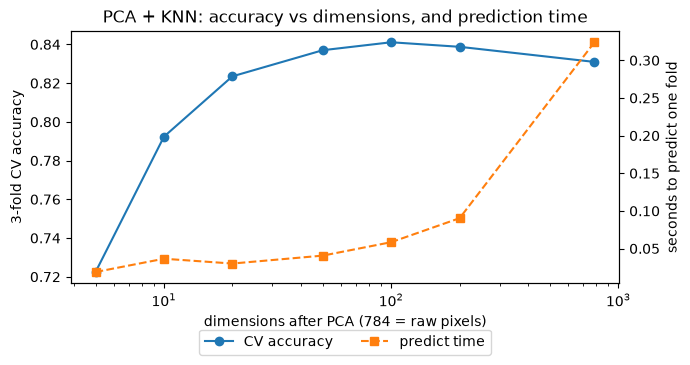

Best: 100 dimensions (0.841) vs raw 784 (0.831) — 5.5× faster to predict


In [47]:
dim_rows = []
for n_components in [5, 10, 20, 50, 100, 200]:
    pipe = make_pipeline(PCA(n_components=n_components, random_state=SEED), KNeighborsClassifier(n_neighbors=5))
    res = cross_validate(pipe, Xf_tr, yf_tr, cv=proj_folds)
    dim_rows.append({"dimensions": n_components, "CV accuracy": res["test_score"].mean(),
                     "predict s per fold": res["score_time"].mean()})
dim_rows.append({"dimensions": 784, "CV accuracy": raw_cv["test_score"].mean(), "predict s per fold": raw_cv["score_time"].mean()})
dims_table = pd.DataFrame(dim_rows).set_index("dimensions")
print(dims_table.round(4))

fig, ax1 = plt.subplots(figsize=(7, 3.5))
ax1.plot(dims_table.index, dims_table["CV accuracy"], "o-", label="CV accuracy")
ax1.set(xscale="log", xlabel="dimensions after PCA (784 = raw pixels)", ylabel="3-fold CV accuracy")
ax2 = ax1.twinx()
ax2.plot(dims_table.index, dims_table["predict s per fold"], "s--", c="tab:orange", label="predict time")
ax2.set_ylabel("seconds to predict one fold")
ax1.set_title("PCA + KNN: accuracy vs dimensions, and prediction time")
fig.legend(loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()
best_dims = int(dims_table["CV accuracy"].idxmax())
print(f"Best: {best_dims} dimensions ({dims_table.loc[best_dims, 'CV accuracy']:.3f}) vs raw 784 "
      f"({dims_table.loc[784, 'CV accuracy']:.3f}) — "
      f"{dims_table.loc[784, 'predict s per fold'] / dims_table.loc[best_dims, 'predict s per fold']:.1f}× faster to predict")

### Step 4 — Grid search: dimensions × k × weights

In [48]:
search = GridSearchCV(
    make_pipeline(PCA(random_state=SEED), KNeighborsClassifier()),
    param_grid={"pca__n_components": [30, 50, 80],
                "kneighborsclassifier__n_neighbors": [3, 5, 9, 15],
                "kneighborsclassifier__weights": ["uniform", "distance"]},
    cv=proj_folds, scoring="accuracy",
)
start = time.perf_counter()
search.fit(Xf_tr, yf_tr)
print(f"grid search: {len(search.cv_results_['params'])} settings × 3 folds in {time.perf_counter() - start:.0f}s")
top = (pd.DataFrame(search.cv_results_)
       .sort_values("rank_test_score")[["param_pca__n_components", "param_kneighborsclassifier__n_neighbors",
                                        "param_kneighborsclassifier__weights", "mean_test_score", "std_test_score"]]
       .head(5))
print(top.to_string(index=False))
print("\nbest settings:", search.best_params_, f"| CV accuracy {search.best_score_:.4f}")

grid search: 24 settings × 3 folds in 6s
 param_pca__n_components  param_kneighborsclassifier__n_neighbors param_kneighborsclassifier__weights  mean_test_score  std_test_score
                      80                                        9                            distance           0.8416          0.0044
                      50                                        9                            distance           0.8412          0.0032
                      80                                        9                             uniform           0.8403          0.0034
                      80                                        5                            distance           0.8401          0.0039
                      50                                        9                             uniform           0.8391          0.0032

best settings: {'kneighborsclassifier__n_neighbors': 9, 'kneighborsclassifier__weights': 'distance', 'pca__n_components': 80} | CV accuracy 0.8416


### Step 5 — The one and only test evaluation

In [49]:
final_model = search.best_estimator_                         # refit on all 20,000 training images
start = time.perf_counter()
test_pred = final_model.predict(Xf_te)
predict_ms_per_image = (time.perf_counter() - start) * 1000 / len(Xf_te)
test_acc, test_macro_f1 = accuracy_score(yf_te, test_pred), f1_score(yf_te, test_pred, average="macro")
print(f"test accuracy {test_acc:.4f} | macro F1 {test_macro_f1:.4f} | {predict_ms_per_image:.3f} ms per image")
print(classification_report(yf_te, test_pred, target_names=class_names, digits=3))

test accuracy 0.8438 | macro F1 0.8437 | 0.010 ms per image
              precision    recall  f1-score   support

 T-shirt/top      0.781     0.840     0.810       400
     Trouser      0.987     0.945     0.966       400
    Pullover      0.780     0.720     0.749       400
       Dress      0.866     0.870     0.868       400
        Coat      0.735     0.775     0.754       400
      Sandal      0.986     0.850     0.913       400
       Shirt      0.617     0.600     0.608       400
     Sneaker      0.865     0.930     0.896       400
         Bag      0.955     0.960     0.958       400
  Ankle boot      0.886     0.948     0.915       400

    accuracy                          0.844      4000
   macro avg      0.846     0.844     0.844      4000
weighted avg      0.846     0.844     0.844      4000



### Step 6 — Error analysis: which clothes get confused?

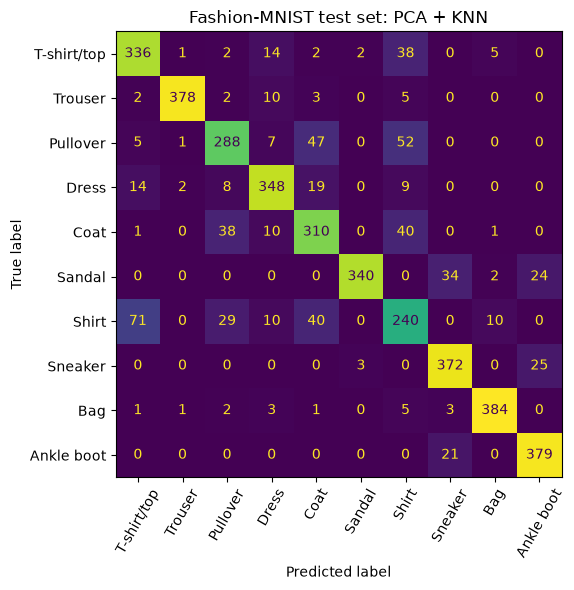

       Shirt predicted as T-shirt/top : 71 images
    Pullover predicted as Shirt       : 52 images
    Pullover predicted as Coat        : 47 images
hardest class: Shirt (recall 0.600) | easiest: Bag (recall 0.960)


In [50]:
cm = confusion_matrix(yf_te, test_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=60, colorbar=False)
ax.set_title("Fashion-MNIST test set: PCA + KNN")
plt.tight_layout()
plt.show()

off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)
pairs_idx = np.dstack(np.unravel_index(np.argsort(off_diag, axis=None)[::-1][:3], cm.shape))[0]
for true_c, pred_c in pairs_idx:
    print(f"{class_names[true_c]:>12s} predicted as {class_names[pred_c]:<12s}: {off_diag[true_c, pred_c]} images")
per_class_recall = cm.diagonal() / cm.sum(axis=1)
print(f"hardest class: {class_names[per_class_recall.argmin()]} (recall {per_class_recall.min():.3f}) | "
      f"easiest: {class_names[per_class_recall.argmax()]} (recall {per_class_recall.max():.3f})")

### Step 7 — Conclusions (computed)

In [51]:
cv_test_gap = test_acc - search.best_score_
dims_gain = dims_table.loc[best_dims, "CV accuracy"] - dims_table.loc[784, "CV accuracy"]
print(f"1. Tuned PCA({search.best_params_['pca__n_components']}) + KNN(k={search.best_params_['kneighborsclassifier__n_neighbors']}, "
      f"{search.best_params_['kneighborsclassifier__weights']}) reached test accuracy {test_acc:.3f} vs a {majority_acc:.3f} majority baseline.")
print(f"2. Test vs CV accuracy gap: {cv_test_gap:+.3f} → "
      f"{'CV was a reliable guide' if abs(cv_test_gap) < 0.02 else 'CV and test disagree; check the sample size or shift'}.")
print(f"3. Reducing 784 pixels to {best_dims} PCA dimensions changed CV accuracy by {dims_gain:+.3f} and cut prediction time "
      f"{dims_table.loc[784, 'predict s per fold'] / dims_table.loc[best_dims, 'predict s per fold']:.1f}× → "
      f"{'fewer, more informative dimensions helped KNN' if dims_gain > 0 else 'PCA mainly bought speed here'}.")
print(f"4. Most confused pair: {class_names[pairs_idx[0][0]]} → {class_names[pairs_idx[0][1]]}; "
      f"hardest class {class_names[per_class_recall.argmin()]} — similar shapes that pixel distances can't separate.")

1. Tuned PCA(80) + KNN(k=9, distance) reached test accuracy 0.844 vs a 0.100 majority baseline.
2. Test vs CV accuracy gap: +0.002 → CV was a reliable guide.
3. Reducing 784 pixels to 100 PCA dimensions changed CV accuracy by +0.010 and cut prediction time 5.5× → fewer, more informative dimensions helped KNN.
4. Most confused pair: Shirt → T-shirt/top; hardest class Shirt — similar shapes that pixel distances can't separate.


**Stretch goals**
1. Replace PCA with `sklearn.manifold` or **UMAP** (`umap-learn`) embeddings fitted inside the pipeline and compare accuracy and speed.
2. Use all 60,000 training images with the `pynndescent` index from Section 12 to find neighbours, and measure how accuracy and latency change.
3. Try `metric="cosine"` on the PCA features, and `StandardScaler` before PCA — which helps?
4. Compare with logistic regression and a random forest on the same folds (Section 13's recipe).

### 🗣️ How to talk about this in an interview
- "I built a PCA + KNN pipeline for Fashion-MNIST, tuned dimensions, k and weights with 3-fold stratified CV on a training sample, and scored the official test images exactly once."
- "PCA was inside the pipeline, so each fold learned its own components: no leakage from validation images."
- "The dimension sweep showed the curse of dimensionality in practice: a few dozen PCA dimensions matched or beat 784 raw pixels while predicting several times faster."
- "Error analysis showed the confusions are between visually similar classes like shirts, T-shirts, pullovers and coats, which is a limit of pixel distance. A CNN or learned embeddings would be the next step."
- "To serve this at scale I'd swap exact search for an ANN index and check recall@k against brute force."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. How does KNN work, and what happens during training?**

<details><summary>Show answer</summary>

- **30-second answer:** Training just stores the data (and optionally builds a search index). To predict, compute the distance from the query to the training points, take the k closest, and return the majority label (classification) or the mean target (regression), optionally weighted by 1/distance.
- **Go deeper:** It's non-parametric and instance-based: model size grows with n. Fit is O(1) for brute force or O(n log n) for a tree, prediction O(n·d) per query for brute force. `predict_proba` is the fraction of neighbours per class.
- **❌ Common wrong answer:** "KNN learns k cluster centres during training" — that's k-means, an unsupervised clustering algorithm.

</details>

**Q2. How do you choose k?**

<details><summary>Show answer</summary>

- **30-second answer:** Cross-validate a grid of values (odd values for binary problems) inside a pipeline with scaling, and pick the best or the largest k within one standard error. Small k = low bias, high variance; large k = smooth, high bias.
- **Go deeper:** A common starting range is 1 to about √n. For regression the variance term is σ²/k while bias grows as neighbours get farther. Distance weights reduce sensitivity to k. With imbalanced classes, very large k drowns the minority class unless you tune the threshold.
- **❌ Common wrong answer:** "Always use k = √n" or "pick the k with the best training accuracy" (k=1 always wins on training data).

</details>

**Q3. Why does KNN need feature scaling?**

<details><summary>Show answer</summary>

- **30-second answer:** Distances add raw feature differences, so a feature measured in thousands dominates one measured in fractions. Standardizing puts features on a comparable scale; on wine it lifted 5-fold accuracy from 0.68 to 0.97.
- **Go deeper:** Fit the scaler on training folds only (inside a `Pipeline`). StandardScaler is the usual choice; MinMaxScaler is sensitive to outliers; RobustScaler helps with heavy tails. Scaling also implicitly *weights* features, so domain-driven weights or metric learning can do better still.
- **❌ Common wrong answer:** "Scaling only matters for gradient descent."

</details>

**Q4. What is the curse of dimensionality, and why does it hurt KNN in particular?**

<details><summary>Show answer</summary>

- **30-second answer:** As dimensions grow, data becomes sparse and pairwise distances concentrate: the nearest and farthest points end up at similar distances, so "nearest" stops meaning "similar". KNN relies entirely on distances, so it degrades quickly, especially with irrelevant features.
- **Go deeper:** To capture a fraction f of uniform data you need a cube with edge $f^{1/d}$ (0.79 for 10% in 10-D). Beyer et al. (1999) proved contrast vanishes under broad conditions. Real data has lower intrinsic dimension, so KNN on PCA or learned embeddings still works. Fixes: feature selection, PCA/embeddings, metric learning.
- **❌ Common wrong answer:** "It just means the computation gets slower." Slowness is real, but the main problem is that distances become uninformative.

</details>

**Q5. Which distance metric would you use, and when?**

<details><summary>Show answer</summary>

- **30-second answer:** Euclidean for scaled continuous features; Manhattan when you want less sensitivity to single large differences or in higher dimensions; cosine for text and embeddings, where direction matters more than length; Hamming (or Jaccard) for binary/categorical codes. Treat the metric as a hyperparameter and cross-validate.
- **Go deeper:** Minkowski p generalizes L1/L2/L∞. On L2-normalized vectors, Euclidean and cosine give the same ranking. Mixed data types need something like Gower distance or one-hot + scaling. Mahalanobis accounts for feature correlations.
- **❌ Common wrong answer:** "Cosine distance is a proper metric like Euclidean" — it violates the triangle inequality, which is one reason KD-trees don't support it.

</details>

**Q6. KD-tree vs ball tree vs brute force?**

<details><summary>Show answer</summary>

- **30-second answer:** KD-trees split on one coordinate at a time and prune boxes: fast for low dimensions (≲ 15–20). Ball trees nest hyperspheres, support more metrics and degrade more gracefully. Brute force computes all distances with vectorized maths and wins in high dimensions, for small n, or for sparse data.
- **Go deeper:** Tree queries are about O(log n) in low d but approach O(n) as d grows because pruning fails (the curse again). scikit-learn's `auto` chooses brute force when d > 15 or k ≥ n/2. `leaf_size` changes speed and memory, not results.
- **❌ Common wrong answer:** "Trees are always faster than brute force." In Section 9 KD-trees were far slower than brute force at d = 64.

</details>

**Q7. Is KNN parametric? How is it different from logistic regression?**

<details><summary>Show answer</summary>

- **30-second answer:** KNN is non-parametric: it keeps all training data and can model any boundary shape, with complexity controlled by k. Logistic regression is parametric: a fixed weight vector, a linear boundary in feature space, O(d) prediction, and calibrated-ish probabilities.
- **Go deeper:** KNN adapts to local structure without feature engineering but needs meaningful distances, scaling and lots of data per dimension. Logistic regression learns feature weights (ignoring irrelevant features), extrapolates, and is tiny to serve. Our noise-column experiment showed LR degrading far less than KNN.
- **❌ Common wrong answer:** "KNN has one parameter, k, so it's parametric." k is a hyperparameter; the "parameters" are the whole training set.

</details>

**Q8. What does Cover & Hart's result say about 1-NN?**

<details><summary>Show answer</summary>

- **30-second answer:** As the training set size goes to infinity, the error rate of the 1-nearest-neighbour classifier is at most twice the Bayes (optimal) error rate. And k-NN with k → ∞ and k/n → 0 converges to the Bayes classifier.
- **Go deeper:** It's an asymptotic statement: the rate of convergence depends heavily on dimension, which is why the guarantee means little for raw high-dimensional data. It explains why KNN is a strong baseline when data is plentiful and low-dimensional.
- **❌ Common wrong answer:** "1-NN is always within 2× the best possible error on my dataset."

</details>

**Q9. How do approximate nearest neighbour indexes work, and what do you trade off?**

<details><summary>Show answer</summary>

- **30-second answer:** They avoid comparing against every vector. HNSW builds a layered proximity graph and greedily walks it; IVF clusters vectors and searches only the closest clusters; product quantization compresses vectors to compare them cheaply. You trade recall (missing some true neighbours) and index build time/memory for much lower query latency.
- **Go deeper:** Tune `efSearch`/`M` (HNSW) or `nprobe`/number of lists (IVF) against recall@k measured on a sample with exact search. HNSW: high recall, memory-heavy; IVF-PQ: compact, lower recall, needs training. Re-rank candidates with exact distances. We measured pynndescent's recall@10 and speed against brute force.
- **❌ Common wrong answer:** "ANN returns the exact neighbours, just faster."

</details>

### 💻 Coding

**Q10. Implement KNN classification in NumPy without looping over queries.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  sq = (Q**2).sum(1)[:, None] + (X**2).sum(1)[None, :] - 2 * Q @ X.T
  nn = np.argpartition(sq, k - 1, axis=1)[:, :k]
  votes = np.eye(n_classes)[y[nn]].sum(axis=1)
  pred = votes.argmax(axis=1)
  ```
- **Go deeper:** Clip negative squared distances to 0 before `sqrt`; sort the k candidates if order matters (distance weights, returning neighbours); chunk queries to bound memory at O(chunk · n); ties go to the lowest label with `argmax`. Our `ScratchKNNClassifier` matched scikit-learn exactly.
- **❌ Common wrong answer:** Using `np.argsort` on the full row (O(n log n) instead of O(n)), or broadcasting to an `(n_q, n, d)` array that doesn't fit in memory.

</details>

**Q11. How would you pick k and the distance weighting in scikit-learn without leakage?**

<details><summary>Show answer</summary>

- **30-second answer:** `GridSearchCV(make_pipeline(StandardScaler(), KNeighborsClassifier()), {"kneighborsclassifier__n_neighbors": [...], "kneighborsclassifier__weights": ["uniform", "distance"]}, cv=StratifiedKFold(5, shuffle=True))` on the training split, then evaluate `best_estimator_` once on the test set.
- **Go deeper:** Add PCA or feature selection as pipeline steps so they're tuned and fitted per fold. For imbalanced data use `scoring="f1"` or `"average_precision"`, and wrap in `TunedThresholdClassifierCV` if the threshold matters. Use nested CV to report an unbiased estimate of the whole tuning procedure.
- **❌ Common wrong answer:** Scaling the full dataset first and then grid-searching on it.

</details>

### 🐛 Debugging Scenarios

**Q12. Your KNN model has 100% training accuracy and 71% test accuracy. What's going on?**

<details><summary>Show answer</summary>

- **30-second answer:** With k=1 (or distance weights) every training point is its own nearest neighbour, so training accuracy is always 100% and tells you nothing. The test score is the real one: check scaling, irrelevant features, and choose k by cross-validation.
- **Go deeper:** Look for features with huge ranges dominating distances (we saw proline take most of the squared distance), ID-like columns, too many dimensions, and duplicates between train and test that inflate results elsewhere. Plot the validation curve over k.
- **❌ Common wrong answer:** "The model is overfitting, so collect more data" without looking at k, scaling and features.

</details>

**Q13. A KNN recommendation endpoint is accurate offline but takes 2 seconds per request in production. What do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Brute-force search over millions of rows is O(n·d) per request. Reduce d (PCA, smaller embeddings, float32), then switch to an ANN index (HNSW/IVF via FAISS or a vector database), precompute neighbours for popular items, and batch queries.
- **Go deeper:** Measure recall@k of the ANN index against exact search on a sample, tune `efSearch`/`nprobe` for the latency budget, shard the index, keep it in memory, and plan index refreshes for new items. A tree index only helps in low dimensions.
- **❌ Common wrong answer:** "Retrain the model to make it faster" — there's nothing to retrain; the cost is the search.

</details>

**Q14. After adding 300 new engineered features, KNN accuracy dropped although each feature looked useful alone. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** Every feature contributes to every distance. Many weak or noisy features swamp the strong ones and push the data into high dimensions where distances concentrate. KNN can't learn to down-weight them.
- **Go deeper:** We showed accuracy dropping by about 0.2 as 200 noise columns were added, while logistic regression barely moved and `SelectKBest` inside the pipeline recovered KNN. Use feature selection, PCA, or a model with learned weights; evaluate with CV.
- **❌ Common wrong answer:** "More features always give the model more information."

</details>

### 🏗️ Design

**Q15. Design a "similar items" feature for an e-commerce catalogue of 50 million products.**

<details><summary>Show answer</summary>

- **30-second answer:** Represent each product as an embedding (image + text encoders, or collaborative filtering vectors), normalize, build an ANN index (HNSW or IVF-PQ) offline, and serve top-k by cosine similarity with a latency budget, then re-rank candidates with business rules (in stock, category, price) or a learned ranker.
- **Go deeper:** Evaluate offline with recall@k against exact search and online with CTR/conversion A/B tests. Handle new products by inserting into the index (or periodic rebuilds), shard by category or region, cache popular results, monitor embedding drift, and re-embed when the encoder changes (index versioning). Memory: 50M × 768 float32 ≈ 143 GB raw, which is why PQ compression or smaller embeddings matter.
- **❌ Common wrong answer:** "Fit `KNeighborsClassifier` on all products and call `kneighbors` per request."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** `KNeighborsClassifier(n_neighbors=1).fit(X, y).score(X, y)` on the wine data (no duplicate rows). What is the result?
<details><summary>Answer</summary>

`1.0` — each training point's nearest neighbour is itself, at distance 0.
</details>

**2.** For a binary problem with `n_neighbors=4` and uniform weights, how many different values can `predict_proba(X)[:, 1]` take?
<details><summary>Answer</summary>

**5**: 0, 0.25, 0.5, 0.75 and 1.
</details>

**3.** What happens with `KNeighborsClassifier(metric="cosine", algorithm="kd_tree").fit(X, y)`?
<details><summary>Answer</summary>

`ValueError` — the KD-tree doesn't support the cosine metric. Use `algorithm="brute"` (or `"auto"`, which picks brute force for cosine).
</details>

**4.** With `weights="distance"`, a query is identical to one training point labelled `1`, and its other 4 neighbours are labelled `0`. What does KNN predict?
<details><summary>Answer</summary>

**`1`** — the zero-distance neighbour gets weight 1 and all others weight 0, so `predict_proba` is `[0, 1]`.
</details>

**5.** `NearestNeighbors().fit(np.random.rand(1000, 64))` with `algorithm="auto"`: which search method does scikit-learn choose?
<details><summary>Answer</summary>

**Brute force** — `auto` switches to brute force when there are more than 15 features (Section 9 prints this).
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Nearest Neighbors user guide](https://scikit-learn.org/stable/modules/neighbors.html) — classification, regression, KD-tree/ball tree, `KNeighborsTransformer`
- [scikit-learn — Probability calibration](https://scikit-learn.org/stable/modules/calibration.html) — for when KNN's coarse probabilities need fixing
- [imbalanced-learn documentation](https://imbalanced-learn.org/stable/) — SMOTE and resampling pipelines
- [PyNNDescent documentation](https://pynndescent.readthedocs.io/en/latest/) — the approximate nearest-neighbour library used in Section 12

### 🎥 Videos
- [StatQuest (Josh Starmer) — K-nearest neighbors, Clearly Explained](https://www.youtube.com/watch?v=HVXime0nQeI) (~6 min) — the core idea with pictures; watch before Section 1
- [Kilian Weinberger (Cornell CS4780) — Lecture 4: Curse of Dimensionality / Perceptron](https://www.youtube.com/watch?v=BbYV8UfMJSA) (~48 min) — a university lecture on why distances concentrate in high dimensions; the first half pairs with Section 7
- [James Briggs — HNSW for Vector Search Explained and Implemented with Faiss](https://www.youtube.com/watch?v=QvKMwLjdK-s) (~35 min) — how the graph index behind most vector databases works; pairs with Section 12

### 📄 Papers
- [Beyer et al. (1999) — When Is "Nearest Neighbor" Meaningful?](https://link.springer.com/chapter/10.1007/3-540-49257-7_15) — the distance-concentration result behind Section 7
- [Malkov & Yashunin (2016) — Efficient and robust approximate nearest neighbor search using Hierarchical Navigable Small World graphs](https://arxiv.org/abs/1603.09320) — the HNSW paper
- [ANN-Benchmarks](https://github.com/erikbern/ann-benchmarks) — recall vs queries-per-second for many ANN libraries on real datasets

### 📘 Books & Courses
- [Cornell CS4780 — Lecture notes: k-nearest neighbors / Curse of Dimensionality](https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote02_kNN.html) — the Cover & Hart bound and the hypercube argument, written clearly
- [An Introduction to Statistical Learning (free PDF)](https://www.statlearning.com/) — Chapters 2–3 cover KNN, bias–variance and the curse of dimensionality

### 🏋️ Practice
- [Kaggle — Fashion-MNIST dataset](https://www.kaggle.com/datasets/zalando-research/fashionmnist) — push the mini project further and compare notebooks from others

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| KNN prediction | vote / average of the k closest training points | `KNeighborsClassifier(n_neighbors=k)`, `KNeighborsRegressor` |
| Lazy learning | fit stores data, predict does the work | fit O(1), brute-force predict O(n·d) per query |
| Distance metrics | define "near" | `metric="minkowski", p=2` (Euclidean), `"manhattan"`, `"cosine"`, `"hamming"` |
| Scaling | equalize feature influence | `make_pipeline(StandardScaler(), KNeighborsClassifier())` |
| Choosing k | bias–variance trade-off | `validation_curve` / `GridSearchCV`; small k overfits, large k underfits |
| Weights | closer neighbours count more | `weights="distance"`, $w_i = 1/d_i$, zero distance → weight 1 |
| Probabilities | fraction of neighbours | $\hat P(c \mid x) = k_c / k$, coarse for small k |
| Curse of dimensionality | distances concentrate | relative contrast → 0; edge $= f^{1/d}$; fix with selection / PCA / embeddings |
| Search structures | exact neighbour search | `algorithm="kd_tree"` (low d), `"ball_tree"`, `"brute"` (high d), `"auto"` |
| Regression | weighted mean of neighbour targets | can't extrapolate beyond seen targets |
| Imbalance | rare class loses votes | `TunedThresholdClassifierCV`, imblearn `SMOTE` inside the pipeline, PR-AUC |
| ANN at scale | fast approximate search | pynndescent `NNDescent`, FAISS HNSW / IVF-PQ; measure recall@k |

## ➡️ What's Next

**[06 · Naive Bayes](06_Naive_Bayes.ipynb)** — KNN estimated class probabilities by counting neighbours; Naive Bayes estimates them with Bayes' theorem and one bold independence assumption, giving one of the fastest classifiers there is and a classic baseline for text and spam filtering.